In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import glob
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import os
import pandas as pd
import gc
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.preprocessing import StandardScaler

2026-07-20 11:44:20.975806: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE3 SSE4.1 SSE4.2 AVX, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
years = [2008, 2009, 2010, 2011, 2012]
original_hrdps_dir = ("/results/forcing/atmospheric/GEM2.5/gemlam")
time_fixed_dir = ("/ocean/dtaneja/MOAD/analysis-dishika/notebooks/TimeFixed")

fixed_2008_filenames = {
    "gemlam_y2008m07d16.nc",
    "gemlam_y2008m07d17.nc",
    "gemlam_y2008m07d18.nc",
    "gemlam_y2008m07d19.nc",
    "gemlam_y2008m07d20.nc",
    "gemlam_y2008m07d21.nc",
    "gemlam_y2008m07d22.nc",
    "gemlam_y2008m07d23.nc",
    'gemlam_y2008m08d10.nc',
    "gemlam_y2008m08d11.nc",
    "gemlam_y2008m08d12.nc",
}

hrdps_files_by_year = {}
for year in years:
    original_files = glob.glob(os.path.join(original_hrdps_dir,f"gemlam_y{year}m??d??.nc"))
    files_by_name = {os.path.basename(file): file for file in original_files}
    if year == 2008:
        for filename in fixed_2008_filenames:
            fixed_file = os.path.join(time_fixed_dir,filename,)
            files_by_name[filename] = fixed_file

    files = [files_by_name[filename] for filename in sorted(files_by_name)]

    hrdps_files_by_year[year] = files

    print(year,":",files[0],"to",files[-1],f"({len(files)} files)")

2008 : /results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2008m01d01.nc to /results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2008m12d31.nc (366 files)
2009 : /results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2009m01d01.nc to /results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2009m12d31.nc (365 files)
2010 : /results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2010m01d01.nc to /results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2010m12d31.nc (365 files)
2011 : /results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2011m01d01.nc to /results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2011m12d31.nc (365 files)
2012 : /results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2012m01d01.nc to /results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2012m12d31.nc (366 files)


In [3]:
# Loading darldsets

weights_pre_file = "/home/sallen/MEOPAR/grid/weights-gem2.5-gemlam_201702_pre22sep11.nc"
weights_post_file = "/home/sallen/MEOPAR/grid/weights-gem2.5-gemlam_201702_22sep11onward.nc"
mesh_mask_file = "/ocean/dtaneja/MOAD/analysis-dishika/grid/mesh_mask202108.nc"

ds_weights_pre = xr.open_dataset(weights_pre_file).load()
ds_weights_post = xr.open_dataset(weights_post_file).load()

with xr.open_dataset(mesh_mask_file) as ds_mesh:
    nemo_lat = ds_mesh["nav_lat"].load()
    nemo_lon = ds_mesh["nav_lon"].load()

In [4]:
# Converts hourly HRDPS longwave_radiation from the 266 × 256 HRDPS grid to the 898 × 398 NEMO grid

transition_time = pd.Timestamp("2011-09-22 00:00:00")

def interpolate_therm_rad_with_weights(therm_rad, ds_weights):
    therm_rad = therm_rad.transpose("time_counter", "y", "x")

    n_time = therm_rad.sizes["time_counter"]
    source_shape = (therm_rad.sizes["y"],therm_rad.sizes["x"])
    n_source_cells = source_shape[0] * source_shape[1]

    source_values = (therm_rad.values.reshape(n_time, n_source_cells).astype(np.float32))
    target_shape = ds_weights["src01"].shape

    interpolated = np.zeros((n_time, target_shape[0], target_shape[1]),dtype=np.float32)

    for n in range(1, 5):
        # The source indexes in the weights file are 1-based
        source_index = (ds_weights[f"src{n:02d}"].values.astype(np.int64)- 1)
        weight = (ds_weights[f"wgt{n:02d}"].values.astype(np.float32))

        interpolated += (source_values[:, source_index]* weight[None, :, :])

    therm_rad_nemo = xr.DataArray(
        interpolated,
        dims=("time_counter", "y", "x"),
        coords={
            "time_counter": therm_rad["time_counter"],
            "nav_lat": (("y", "x"), nemo_lat.values),
            "nav_lon": (("y", "x"), nemo_lon.values),
        },
        name="therm_rad"
    )

    therm_rad_nemo.attrs = therm_rad.attrs.copy()
    therm_rad_nemo.attrs["grid"] = "SalishSeaCast NEMO grid"
    therm_rad_nemo.attrs["interpolation"] = (
        "Four-source weighted HRDPS-to-NEMO interpolation"
    )
    return therm_rad_nemo

In [5]:
# Open file and interpolates

def extract_and_interpolate_hourly_therm_rad(file):
    with xr.open_dataset(file) as ds:
        therm_rad = ds["therm_rad"].sortby("time_counter")
        time_index = therm_rad.get_index("time_counter")

        if time_index.has_duplicates:
            unique_mask = ~time_index.duplicated()
            therm_rad = therm_rad.isel(time_counter=unique_mask)

        therm_rad = therm_rad.load()

    times = pd.to_datetime(therm_rad["time_counter"].values)

    before_transition = times < transition_time
    after_transition = times >= transition_time

    pieces = []

    if before_transition.any():
        therm_rad_pre = therm_rad.isel(time_counter=np.where(before_transition)[0])
        interpolated_pre = interpolate_therm_rad_with_weights(therm_rad_pre,ds_weights_pre)
        pieces.append(interpolated_pre)

    if after_transition.any():
        therm_rad_post = therm_rad.isel(time_counter=np.where(after_transition)[0])
        interpolated_post = interpolate_therm_rad_with_weights(therm_rad_post,ds_weights_post)
        pieces.append(interpolated_post)

    therm_rad_nemo = xr.concat(pieces,dim="time_counter").sortby("time_counter")
    return therm_rad_nemo

In [6]:
sample_pre_file = hrdps_files_by_year[2008][0]
therm_rad_nemo_pre = extract_and_interpolate_hourly_therm_rad(sample_pre_file)

print("Shape:", therm_rad_nemo_pre.shape)
print("Time range:",therm_rad_nemo_pre.time_counter.values[0],"to",therm_rad_nemo_pre.time_counter.values[-1])

Shape: (24, 898, 398)
Time range: 2008-01-01T00:00:00.000000000 to 2008-01-01T23:00:00.000000000


In [7]:
sample_post_file = hrdps_files_by_year[2012][0]
therm_rad_nemo_post = extract_and_interpolate_hourly_therm_rad(sample_post_file)

print("Shape:", therm_rad_nemo_post.shape)
print("Time range:",therm_rad_nemo_post.time_counter.values[0],"to",therm_rad_nemo_post.time_counter.values[-1])

Shape: (24, 898, 398)
Time range: 2012-01-01T00:00:00.000000000 to 2012-01-01T23:00:00.000000000


In [8]:
with xr.open_dataset(mesh_mask_file) as ds_mesh:
    water_mask = (ds_mesh["tmask"].isel(t=0, z=0).load().values.astype(bool))
    nemo_lat_2d = ds_mesh["nav_lat"].load().values
    nemo_lon_2d = ds_mesh["nav_lon"].load().values
nemo_j, nemo_i = np.where(water_mask)
water_flat_indices = np.flatnonzero(water_mask.reshape(-1))
nemo_water_lat = nemo_lat_2d[water_mask]
nemo_water_lon = nemo_lon_2d[water_mask]
n_water = len(water_flat_indices)
print("NEMO grid shape:", water_mask.shape)
print("Number of surface water cells:", n_water)

NEMO grid shape: (898, 398)
Number of surface water cells: 81383


In [9]:
def process_daily_file_to_3h_water(file):
    therm_rad_nemo_hourly = extract_and_interpolate_hourly_therm_rad(file)
    n_time = therm_rad_nemo_hourly.sizes["time_counter"]

    therm_rad_water_values = (therm_rad_nemo_hourly.values.reshape(n_time, -1)[:, water_flat_indices].astype(np.float32))
    therm_rad_water_hourly = xr.DataArray(therm_rad_water_values,dims=("time_counter", "water_cell"),coords={
            "time_counter": therm_rad_nemo_hourly["time_counter"].values,
            "water_cell": np.arange(n_water, dtype=np.int32),},name="therm_rad",attrs=therm_rad_nemo_hourly.attrs,)

    therm_rad_water_3h = therm_rad_water_hourly.resample(time_counter="3h",label="left",closed="left",origin="start_day",).mean()
    return therm_rad_water_3h.load()

In [10]:
test_file = hrdps_files_by_year[2008][0]

test_3h = process_daily_file_to_3h_water(test_file)

print(test_3h)
print("Shape:", test_3h.shape)
print("Times:", test_3h.time_counter.values)

<xarray.DataArray 'therm_rad' (time_counter: 8, water_cell: 81383)> Size: 3MB
array([[254.25856, 254.50563, 254.80165, ..., 212.44531, 211.2187 ,
        209.82051],
       [254.0562 , 254.50995, 255.03642, ..., 263.59375, 261.60287,
        259.37183],
       [282.40344, 283.60526, 284.91504, ..., 282.67923, 281.46408,
        280.12332],
       ...,
       [270.80984, 271.97336, 273.18423, ..., 291.6092 , 291.0622 ,
        290.4569 ],
       [313.41724, 313.37048, 313.29858, ..., 296.4727 , 296.3238 ,
        296.16672],
       [327.19403, 327.20743, 327.24356, ..., 301.322  , 301.7306 ,
        302.15787]], dtype=float32)
Coordinates:
  * time_counter  (time_counter) datetime64[ns] 64B 2008-01-01 ... 2008-01-01...
  * water_cell    (water_cell) int32 326kB 0 1 2 3 4 ... 81379 81380 81381 81382
Attributes:
    level:          surface
    long_name:      Downward Long-Wave Radiation Flux
    standard_name:  net_downward_longwave_flux_in_air
    units:          W/m^2
    comment:     

In [11]:
# # Run only once
# output_dir = ("/ocean/dtaneja/MOAD/analysis-dishika/notebooks/data/hrdps_nemo_3h")
# os.makedirs(output_dir, exist_ok=True)
# hrdps_nemo_processed_files = []

# for year in years:
#     files = sorted(hrdps_files_by_year[year])
#     print(f"\nProcessing {year}: {len(files)} daily files")
#     daily_3h_results = []
#     for file_number, file in enumerate(files, start=1):
#         daily_3h = process_daily_file_to_3h_water(file)
#         daily_3h_results.append(daily_3h)

#         if (file_number == 1 or file_number % 25 == 0 or file_number == len(files)):
#             print(f"{year}: processed "f"{file_number}/{len(files)} files")

#     therm_rad_year = xr.concat(daily_3h_results,dim="time_counter",)
#     therm_rad_year = therm_rad_year.sortby("time_counter")
#     time_index = therm_rad_year.get_index("time_counter")

#     if time_index.has_duplicates:
#         unique_mask = ~time_index.duplicated()
#         therm_rad_year = therm_rad_year.isel(time_counter=unique_mask)

#     ds_year = therm_rad_year.to_dataset(name="therm_rad")

#     ds_year = ds_year.assign_coords(
#         nemo_j=("water_cell",nemo_j.astype(np.int32),),
#         nemo_i=("water_cell",nemo_i.astype(np.int32),),
#         nav_lat=("water_cell",nemo_water_lat.astype(np.float32),),
#         nav_lon=("water_cell",nemo_water_lon.astype(np.float32),),)

#     ds_year.attrs["description"] = ("Raw hourly HRDPS therm_rad interpolated onto NEMO surface water cells, then resampled to three-hourly means.")

#     output_file = (f"{output_dir}/"f"HRDPS_NEMO_{year}_therm_rad_3h.nc")
#     encoding = {"therm_rad": {"dtype": "float32","zlib": True,"complevel": 4,}}
#     ds_year.to_netcdf(output_file,engine="netcdf4",encoding=encoding,)
#     hrdps_nemo_processed_files.append(output_file)

#     print("Saved:", output_file)
#     print("Shape:", ds_year["therm_rad"].shape)
#     print("Time range:",ds_year.time_counter.values[0],"to",ds_year.time_counter.values[-1],)
#     del daily_3h_results
#     del therm_rad_year
#     del ds_year

#     gc.collect()

In [12]:
# # Run only once
# output_dir = ("/ocean/dtaneja/MOAD/analysis-dishika/notebooks/data/hrdps_nemo_3h")
# os.makedirs(output_dir, exist_ok=True)
# hrdps_nemo_processed_files = []

# for year in [2008]:
#     files = hrdps_files_by_year[year]
#     print(f"\nProcessing {year}: {len(files)} daily files")
#     daily_3h_results = []
#     for file_number, file in enumerate(files, start=1):
#         daily_3h = process_daily_file_to_3h_water(file)
#         daily_3h_results.append(daily_3h)

#         if (file_number == 1 or file_number % 25 == 0 or file_number == len(files)):
#             print(f"{year}: processed "f"{file_number}/{len(files)} files")

#     therm_rad_year = xr.concat(daily_3h_results,dim="time_counter",)
#     therm_rad_year = therm_rad_year.sortby("time_counter")
#     time_index = therm_rad_year.get_index("time_counter")

#     if time_index.has_duplicates:
#         unique_mask = ~time_index.duplicated()
#         therm_rad_year = therm_rad_year.isel(time_counter=unique_mask)

#     ds_year = therm_rad_year.to_dataset(name="therm_rad")

#     ds_year = ds_year.assign_coords(
#         nemo_j=("water_cell",nemo_j.astype(np.int32),),
#         nemo_i=("water_cell",nemo_i.astype(np.int32),),
#         nav_lat=("water_cell",nemo_water_lat.astype(np.float32),),
#         nav_lon=("water_cell",nemo_water_lon.astype(np.float32),),)

#     ds_year.attrs["description"] = ("Raw hourly HRDPS therm_rad interpolated onto NEMO surface water cells, then resampled to three-hourly means.")

#     output_file = (f"{output_dir}/"f"HRDPS_NEMO_{year}_therm_rad_3h.nc")
#     encoding = {"therm_rad": {"dtype": "float32","zlib": True,"complevel": 4,}}
#     ds_year.to_netcdf(output_file,engine="netcdf4",encoding=encoding,)
#     hrdps_nemo_processed_files.append(output_file)

#     print("Saved:", output_file)
#     print("Shape:", ds_year["therm_rad"].shape)
#     print("Time range:",ds_year.time_counter.values[0],"to",ds_year.time_counter.values[-1],)
#     del daily_3h_results
#     del therm_rad_year
#     del ds_year

#     gc.collect()

In [13]:
hrdps_nemo_files = sorted(glob.glob("/ocean/dtaneja/MOAD/analysis-dishika/notebooks/data/hrdps_nemo_3h/HRDPS_NEMO_*_therm_rad_3h.nc"))
ds_hrdps_nemo = xr.open_mfdataset(hrdps_nemo_files,combine="by_coords")

ds_hrdps_nemo = ds_hrdps_nemo.sortby("time_counter")

print(ds_hrdps_nemo)
print("First time:", ds_hrdps_nemo.time_counter.values[0])
print("Last time: ", ds_hrdps_nemo.time_counter.values[-1])
print("Shape:", ds_hrdps_nemo["therm_rad"].shape)

<xarray.Dataset> Size: 5GB
Dimensions:       (time_counter: 14608, water_cell: 81383)
Coordinates:
  * time_counter  (time_counter) datetime64[ns] 117kB 2008-01-01 ... 2012-12-...
  * water_cell    (water_cell) int32 326kB 0 1 2 3 4 ... 81379 81380 81381 81382
    nemo_j        (water_cell) int32 326kB dask.array<chunksize=(81383,), meta=np.ndarray>
    nemo_i        (water_cell) int32 326kB dask.array<chunksize=(81383,), meta=np.ndarray>
    nav_lat       (water_cell) float32 326kB dask.array<chunksize=(81383,), meta=np.ndarray>
    nav_lon       (water_cell) float32 326kB dask.array<chunksize=(81383,), meta=np.ndarray>
Data variables:
    therm_rad     (time_counter, water_cell) float32 5GB dask.array<chunksize=(366, 10173), meta=np.ndarray>
Attributes:
    description:  Raw hourly HRDPS therm_rad interpolated onto NEMO surface w...
First time: 2008-01-01T00:00:00.000000000
Last time:  2012-12-31T21:00:00.000000000
Shape: (14608, 81383)


In [14]:
# Validation: 2008
ds_hrdps_val = ds_hrdps_nemo.sel(time_counter=slice("2008-01-01", "2008-12-31 23:59:59"))
# Training: 2009–2011
ds_hrdps_train = ds_hrdps_nemo.sel(time_counter=slice("2009-01-01", "2011-12-31 23:59:59"))
# Testing: 2012
ds_hrdps_test = ds_hrdps_nemo.sel(time_counter=slice("2012-01-01", "2012-12-31 23:59:59"))

In [15]:
canrcm_years = [2008, 2009, 2010, 2011, 2012]
canrcm_rlds_files = []

for year in canrcm_years:
    matches = sorted(glob.glob(f"/results/forcing/CanRCM5/*_{year}01_{year}12_3h_rlds.nc"))
    canrcm_rlds_files.append(matches[0])

print("CanRCM files:")
for file in canrcm_rlds_files:
    print(file)

CanRCM files:
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_200801_200812_3h_rlds.nc
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_200901_200912_3h_rlds.nc
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_201001_201012_3h_rlds.nc
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_201101_201112_3h_rlds.nc
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_201201_201212_3h_rlds.nc


In [16]:
from datetime import timedelta
ds_canrcm = xr.open_mfdataset(canrcm_rlds_files,combine="by_coords")
ds_canrcm = ds_canrcm.sortby("time")
shifted_time = np.array([time_value - timedelta(hours=3)for time_value in ds_canrcm["time"].values])
ds_canrcm = ds_canrcm.assign_coords(time=("time", shifted_time))

print(ds_canrcm)
print("First timestamp:", ds_canrcm.time.values[0])
print("Last timestamp: ", ds_canrcm.time.values[-1])

<xarray.Dataset> Size: 7GB
Dimensions:       (time: 14600, bnds: 2, rlat: 320, rlon: 360)
Coordinates:
  * time          (time) object 117kB 2008-01-01 00:00:00 ... 2012-12-31 21:0...
  * rlat          (rlat) float64 3kB -35.11 -34.89 -34.67 ... 34.63 34.85 35.07
  * rlon          (rlon) float64 3kB -39.27 -39.05 -38.83 ... 39.27 39.49 39.71
    lon           (rlat, rlon) float64 922kB dask.array<chunksize=(320, 360), meta=np.ndarray>
    lat           (rlat, rlon) float64 922kB dask.array<chunksize=(320, 360), meta=np.ndarray>
Dimensions without coordinates: bnds
Data variables:
    time_bnds     (time, bnds) object 234kB dask.array<chunksize=(2920, 2), meta=np.ndarray>
    rotated_pole  (time) |S1 15kB b'' b'' b'' b'' b'' ... b'' b'' b'' b'' b''
    rlds          (time, rlat, rlon) float32 7GB dask.array<chunksize=(2920, 320, 360), meta=np.ndarray>
Attributes: (12/17)
    title:                          CanRCM4 model output prepared for CORDEX ...
    institution:                    

/tmp/ipykernel_1056808/2851013810.py:2: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds_canrcm = xr.open_mfdataset(canrcm_rlds_files,combine="by_coords")


In [17]:
nemo_water_lat = ds_hrdps_nemo["nav_lat"].values
nemo_water_lon = ds_hrdps_nemo["nav_lon"].values

nemo_water_lon_normalized = ((nemo_water_lon + 180) % 360) - 180

lat_min = float(np.nanmin(nemo_water_lat))
lat_max = float(np.nanmax(nemo_water_lat))

lon_min = float(np.nanmin(nemo_water_lon_normalized))
lon_max = float(np.nanmax(nemo_water_lon_normalized))

print("NEMO latitude range:", lat_min, "to", lat_max)
print("NEMO longitude range:", lon_min, "to", lon_max)

NEMO latitude range: 47.06300735473633 to 50.92766571044922
NEMO longitude range: -126.14797973632812 to -122.22117614746094


In [18]:
lat_canrcm = ds_canrcm["lat"]
lon_canrcm = ds_canrcm["lon"]

lon_canrcm_normalized = ((lon_canrcm + 180) % 360) - 180
canrcm_region_mask = ((lat_canrcm >= lat_min)& (lat_canrcm <= lat_max)
                      & (lon_canrcm_normalized >= lon_min) & (lon_canrcm_normalized <= lon_max))

rlat_indices, rlon_indices = np.where(canrcm_region_mask.values)

rlat_min = rlat_indices.min()
rlat_max = rlat_indices.max()

rlon_min = rlon_indices.min()
rlon_max = rlon_indices.max()

print("CanRCM rlat indices:", rlat_min, "to", rlat_max)
print("CanRCM rlon indices:", rlon_min, "to", rlon_max)

ds_canrcm_cut = (ds_canrcm[["rlds"]].isel(rlat=slice(rlat_min, rlat_max + 1),rlon=slice(rlon_min, rlon_max + 1)))
print(ds_canrcm_cut)

CanRCM rlat indices: 171 to 190
CanRCM rlon indices: 91 to 107
<xarray.Dataset> Size: 20MB
Dimensions:  (time: 14600, rlat: 20, rlon: 17)
Coordinates:
  * time     (time) object 117kB 2008-01-01 00:00:00 ... 2012-12-31 21:00:00
  * rlat     (rlat) float64 160B 2.51 2.73 2.95 3.17 ... 6.03 6.25 6.47 6.69
  * rlon     (rlon) float64 136B -19.25 -19.03 -18.81 ... -16.17 -15.95 -15.73
    lon      (rlat, rlon) float64 3kB dask.array<chunksize=(20, 17), meta=np.ndarray>
    lat      (rlat, rlon) float64 3kB dask.array<chunksize=(20, 17), meta=np.ndarray>
Data variables:
    rlds     (time, rlat, rlon) float32 20MB dask.array<chunksize=(2920, 20, 17), meta=np.ndarray>
Attributes: (12/17)
    title:                          CanRCM4 model output prepared for CORDEX ...
    institution:                    CCCma (Canadian Centre for Climate Modell...
    institute_id:                   CCCma
    driving_experiment:             , , r1i1p1
    driving_model_ensemble_member:  r1i1p1
    realization

In [19]:
# Validation: 2008
ds_canrcm_val = ds_canrcm_cut.sel(time=slice("2008-01-01","2008-12-31 23:59:59"))
# Training: 2009–2011
ds_canrcm_train = ds_canrcm_cut.sel(time=slice("2009-01-01","2011-12-31 23:59:59"))
# Testing: 2012
ds_canrcm_test = ds_canrcm_cut.sel(time=slice("2012-01-01","2012-12-31 23:59:59"))

In [20]:
def time_to_string(value):
    if isinstance(value, np.datetime64):
        return np.datetime_as_string(value,unit="s").replace("T", " ")

    if hasattr(value, "strftime"):
        return value.strftime("%Y-%m-%d %H:%M:%S")

    raise TypeError(f"Unsupported time type: {type(value)}")


def align_time_pair(ds_canrcm_split, ds_hrdps_split):
    canrcm_times = np.array([time_to_string(t)for t in ds_canrcm_split["time"].values])
    hrdps_times = np.array([time_to_string(t)for t in ds_hrdps_split["time_counter"].values])
    common_times, canrcm_idx, hrdps_idx = np.intersect1d(canrcm_times,hrdps_times,return_indices=True)
    ds_canrcm_aligned = ds_canrcm_split.isel(time=canrcm_idx)
    ds_hrdps_aligned = ds_hrdps_split.isel(time_counter=hrdps_idx)
    return ds_canrcm_aligned, ds_hrdps_aligned

In [21]:
canrcm_times = np.array([time_to_string(time) for time in ds_canrcm_val["time"].values])
hrdps_times = np.array([time_to_string(time) for time in ds_hrdps_val["time_counter"].values])

canrcm_not_in_hrdps = np.setdiff1d(canrcm_times, hrdps_times)
hrdps_not_in_canrcm = np.setdiff1d(hrdps_times, canrcm_times)

print("CanRCM timestamps not in HRDPS:", len(canrcm_not_in_hrdps))
print(canrcm_not_in_hrdps)

print("\nHRDPS timestamps not in CanRCM:", len(hrdps_not_in_canrcm))
print(hrdps_not_in_canrcm)

CanRCM timestamps not in HRDPS: 0
[]

HRDPS timestamps not in CanRCM: 8
['2008-02-29 00:00:00' '2008-02-29 03:00:00' '2008-02-29 06:00:00'
 '2008-02-29 09:00:00' '2008-02-29 12:00:00' '2008-02-29 15:00:00'
 '2008-02-29 18:00:00' '2008-02-29 21:00:00']


In [22]:
ds_canrcm_val, ds_hrdps_val = align_time_pair(ds_canrcm_val,ds_hrdps_val)
ds_canrcm_train, ds_hrdps_train = align_time_pair(ds_canrcm_train,ds_hrdps_train)
ds_canrcm_test, ds_hrdps_test = align_time_pair(ds_canrcm_test,ds_hrdps_test)

In [23]:
print("Validation:")
print("HRDPS:", ds_hrdps_val.sizes["time_counter"])
print("CanRCM:", ds_canrcm_val.sizes["time"])

print("\nTraining:")
print("HRDPS:", ds_hrdps_train.sizes["time_counter"])
print("CanRCM:", ds_canrcm_train.sizes["time"])

print("\nTesting:")
print("HRDPS:", ds_hrdps_test.sizes["time_counter"])
print("CanRCM:", ds_canrcm_test.sizes["time"])

assert ds_hrdps_val.sizes["time_counter"] == ds_canrcm_val.sizes["time"]
assert ds_hrdps_train.sizes["time_counter"] == ds_canrcm_train.sizes["time"]
assert ds_hrdps_test.sizes["time_counter"] == ds_canrcm_test.sizes["time"]

Validation:
HRDPS: 2920
CanRCM: 2920

Training:
HRDPS: 8760
CanRCM: 8760

Testing:
HRDPS: 2912
CanRCM: 2912


In [ ]:
X_hrdps_train_raw = (ds_hrdps_train["therm_rad"].values.astype(np.float32))
X_hrdps_val_raw = (ds_hrdps_val["therm_rad"].values.astype(np.float32))
X_hrdps_test_raw = (ds_hrdps_test["therm_rad"].values.astype(np.float32))

print("Raw HRDPS-NEMO train:", X_hrdps_train_raw.shape)
print("Raw HRDPS-NEMO val:  ", X_hrdps_val_raw.shape)
print("Raw HRDPS-NEMO test: ", X_hrdps_test_raw.shape)

Raw HRDPS-NEMO train: (8760, 81383)
Raw HRDPS-NEMO val:   (2920, 81383)
Raw HRDPS-NEMO test:  (2912, 81383)


In [25]:
valid_fraction_hrdps = np.isfinite(X_hrdps_train_raw).mean(axis=0)
valid_nemo_cols = valid_fraction_hrdps > 0.95

X_hrdps_train = X_hrdps_train_raw[:, valid_nemo_cols].copy()
X_hrdps_val = X_hrdps_val_raw[:, valid_nemo_cols].copy()
X_hrdps_test = X_hrdps_test_raw[:, valid_nemo_cols].copy()

hrdps_col_mean = np.nanmean(X_hrdps_train,axis=0)

if not np.all(np.isfinite(hrdps_col_mean)):
    raise ValueError(
        "At least one retained NEMO cell has a non-finite training mean."
    )


def fill_with_training_mean(X, training_mean):
    X = X.copy()
    rows, cols = np.where(~np.isfinite(X))
    X[rows, cols] = training_mean[cols]
    return X


X_hrdps_train = fill_with_training_mean(X_hrdps_train,hrdps_col_mean)
X_hrdps_val = fill_with_training_mean(X_hrdps_val,hrdps_col_mean)
X_hrdps_test = fill_with_training_mean(X_hrdps_test,hrdps_col_mean)

print("Valid NEMO cells:", valid_nemo_cols.sum())
print("Final HRDPS train:", X_hrdps_train.shape)
print("Final HRDPS val:  ", X_hrdps_val.shape)
print("Final HRDPS test: ", X_hrdps_test.shape)

Valid NEMO cells: 81383
Final HRDPS train: (8760, 81383)
Final HRDPS val:   (2920, 81383)
Final HRDPS test:  (2912, 81383)


In [ ]:
valid_water_cell = (ds_hrdps_train["water_cell"].values[valid_nemo_cols])
valid_nemo_j = (ds_hrdps_train["nemo_j"].values[valid_nemo_cols])
valid_nemo_i = (ds_hrdps_train["nemo_i"].values[valid_nemo_cols])
valid_nemo_lat = (ds_hrdps_train["nav_lat"].values[valid_nemo_cols])
valid_nemo_lon = (ds_hrdps_train["nav_lon"].values[valid_nemo_cols])
print("Saved coordinate count:", len(valid_water_cell))

Saved coordinate count: 81383


In [27]:
def make_canrcm_matrix(da):
    da = da.transpose("time", "rlat", "rlon")
    n_time = da.sizes["time"]
    return (da.values.reshape(n_time, -1).astype(np.float32))

X_canrcm_train_raw = make_canrcm_matrix(ds_canrcm_train["rlds"])
X_canrcm_val_raw = make_canrcm_matrix(ds_canrcm_val["rlds"])
X_canrcm_test_raw = make_canrcm_matrix(ds_canrcm_test["rlds"])

print("Raw CanRCM train:", X_canrcm_train_raw.shape)
print("Raw CanRCM val:  ", X_canrcm_val_raw.shape)
print("Raw CanRCM test: ", X_canrcm_test_raw.shape)

Raw CanRCM train: (8760, 340)
Raw CanRCM val:   (2920, 340)
Raw CanRCM test:  (2912, 340)


In [28]:
valid_fraction_canrcm = np.isfinite(X_canrcm_train_raw).mean(axis=0)
valid_canrcm_cols = valid_fraction_canrcm > 0.95

X_canrcm_train = X_canrcm_train_raw[:,valid_canrcm_cols].copy()
X_canrcm_val = X_canrcm_val_raw[:,valid_canrcm_cols].copy()
X_canrcm_test = X_canrcm_test_raw[:,valid_canrcm_cols].copy()
canrcm_col_mean = np.nanmean(X_canrcm_train,axis=0)

if not np.all(np.isfinite(canrcm_col_mean)):
    raise ValueError(
        "At least one retained CanRCM cell has a non-finite training mean."
    )

X_canrcm_train = fill_with_training_mean(X_canrcm_train,canrcm_col_mean)
X_canrcm_val = fill_with_training_mean(X_canrcm_val,canrcm_col_mean)
X_canrcm_test = fill_with_training_mean(X_canrcm_test,canrcm_col_mean)
print("Final CanRCM train:", X_canrcm_train.shape)
print("Final CanRCM val:  ", X_canrcm_val.shape)
print("Final CanRCM test: ", X_canrcm_test.shape)

Final CanRCM train: (8760, 340)
Final CanRCM val:   (2920, 340)
Final CanRCM test:  (2912, 340)


In [29]:
hrdps_variance_threshold = 0.98
max_hrdps_pcs = min(300,X_hrdps_train.shape[0] - 1,X_hrdps_train.shape[1])
pca_hrdps = PCA(n_components=max_hrdps_pcs,svd_solver="randomized",random_state=0)
hrdps_train_scores_all = pca_hrdps.fit_transform(X_hrdps_train)
hrdps_cumulative_variance = np.cumsum(pca_hrdps.explained_variance_ratio_)
print("HRDPS PCA components:", pca_hrdps.components_.shape)
print("HRDPS training scores:", hrdps_train_scores_all.shape)
print("Variance explained by all searched PCs:",hrdps_cumulative_variance[-1])

HRDPS PCA components: (300, 81383)
HRDPS training scores: (8760, 300)
Variance explained by all searched PCs: 0.9955478


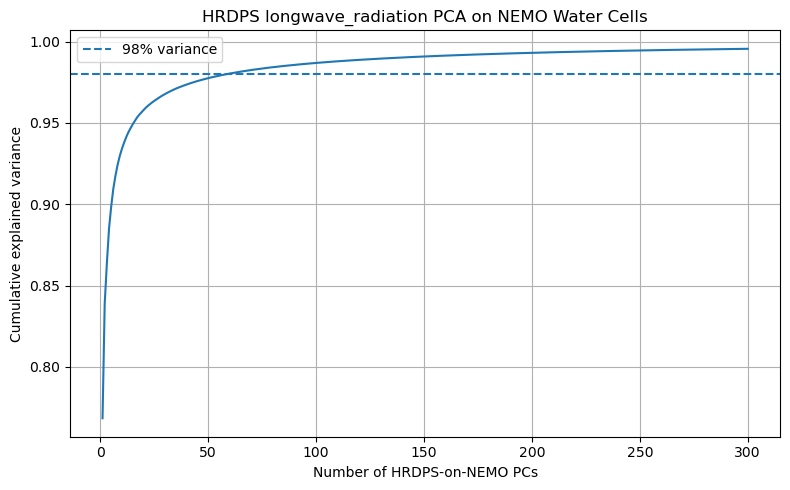

In [30]:
plt.figure(figsize=(8, 5))
plt.plot(np.arange(1, len(hrdps_cumulative_variance) + 1),hrdps_cumulative_variance)
plt.axhline(hrdps_variance_threshold,linestyle="--",label="98% variance")
plt.xlabel("Number of HRDPS-on-NEMO PCs")
plt.ylabel("Cumulative explained variance")
plt.title("HRDPS longwave_radiation PCA on NEMO Water Cells")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [31]:
threshold_indices = np.where(hrdps_cumulative_variance >= hrdps_variance_threshold)[0]
n_hrdps_pcs = threshold_indices[0] + 1
print("Selected HRDPS PCs:", n_hrdps_pcs)
print("Cumulative variance:",hrdps_cumulative_variance[n_hrdps_pcs - 1])

Selected HRDPS PCs: 59
Cumulative variance: 0.9801047


In [32]:
hrdps_train_scores = hrdps_train_scores_all[:, :n_hrdps_pcs]
hrdps_val_scores = pca_hrdps.transform(X_hrdps_val)[:, :n_hrdps_pcs]
hrdps_test_scores = pca_hrdps.transform(X_hrdps_test)[:, :n_hrdps_pcs]

print("HRDPS train scores:", hrdps_train_scores.shape)
print("HRDPS val scores:  ", hrdps_val_scores.shape)
print("HRDPS test scores: ", hrdps_test_scores.shape)

HRDPS train scores: (8760, 59)
HRDPS val scores:   (2920, 59)
HRDPS test scores:  (2912, 59)


In [33]:
max_canrcm_pcs = min(100,X_canrcm_train.shape[0] - 1,X_canrcm_train.shape[1])
pca_canrcm = PCA(n_components=max_canrcm_pcs,svd_solver="randomized",random_state=0)
canrcm_train_scores_all = pca_canrcm.fit_transform(X_canrcm_train)
canrcm_val_scores_all = pca_canrcm.transform(X_canrcm_val)
canrcm_test_scores_all = pca_canrcm.transform(X_canrcm_test)
canrcm_cumulative_variance = np.cumsum(pca_canrcm.explained_variance_ratio_)

print("CanRCM PCA components:", pca_canrcm.components_.shape)
print("CanRCM train scores:", canrcm_train_scores_all.shape)
print("CanRCM val scores:  ", canrcm_val_scores_all.shape)
print("CanRCM test scores: ", canrcm_test_scores_all.shape)

CanRCM PCA components: (100, 340)
CanRCM train scores: (8760, 100)
CanRCM val scores:   (2920, 100)
CanRCM test scores:  (2912, 100)


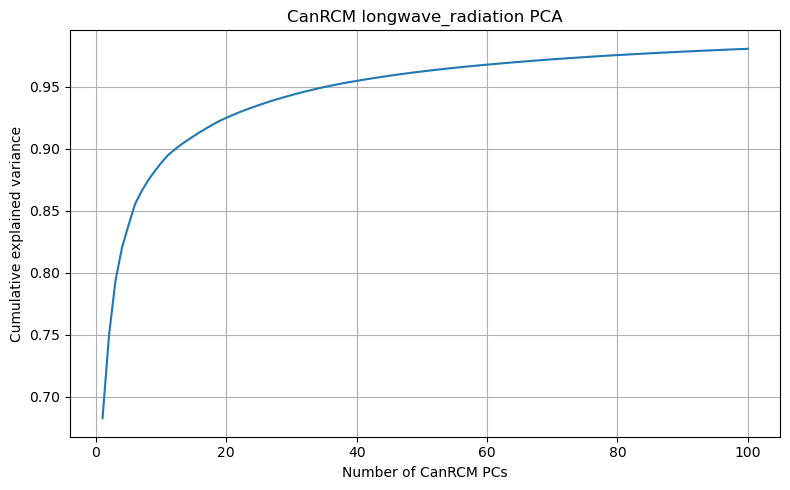

In [34]:
plt.figure(figsize=(8, 5))
plt.plot(np.arange(1, len(canrcm_cumulative_variance) + 1),canrcm_cumulative_variance)
plt.xlabel("Number of CanRCM PCs")
plt.ylabel("Cumulative explained variance")
plt.title("CanRCM longwave_radiation PCA")
plt.grid(True)
plt.tight_layout()
plt.show()

In [35]:
canrcm_pc_candidates = range(1,max_canrcm_pcs + 1)
val_r2_scores = []
for n_canrcm_pcs_candidate in canrcm_pc_candidates:
    X_train_pc = canrcm_train_scores_all[:,:n_canrcm_pcs_candidate]
    X_val_pc = canrcm_val_scores_all[:,:n_canrcm_pcs_candidate]
    model = LinearRegression()
    model.fit(X_train_pc,hrdps_train_scores)
    hrdps_val_scores_pred_candidate = model.predict(X_val_pc)
    val_r2 = r2_score(hrdps_val_scores,hrdps_val_scores_pred_candidate,multioutput="variance_weighted")
    val_r2_scores.append(val_r2)
val_r2_scores = np.array(val_r2_scores)

In [36]:
best_index = np.nanargmax(val_r2_scores)
n_canrcm_pcs = list(canrcm_pc_candidates)[best_index]
best_val_r2 = val_r2_scores[best_index]

print("Best number of CanRCM PCs:", n_canrcm_pcs)
print("Best validation PC-space R²:", best_val_r2)

Best number of CanRCM PCs: 73
Best validation PC-space R²: 0.6189713478088379


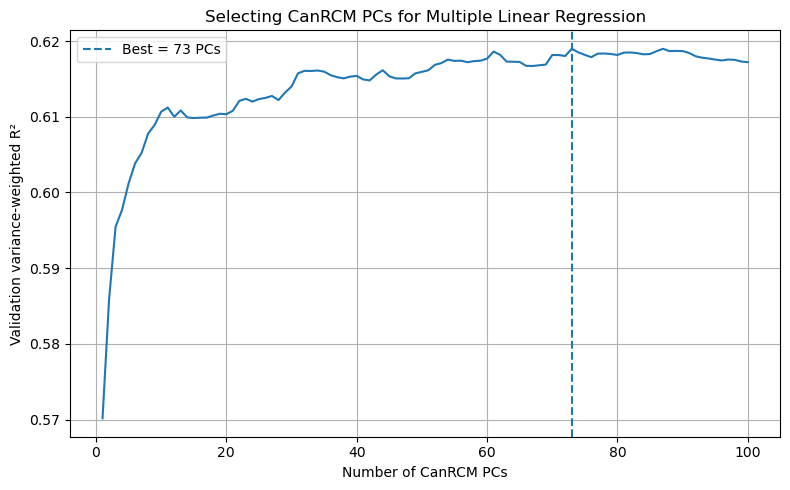

In [37]:
plt.figure(figsize=(8, 5))
plt.plot(list(canrcm_pc_candidates),val_r2_scores)
plt.axvline(n_canrcm_pcs,linestyle="--",label=f"Best = {n_canrcm_pcs} PCs")
plt.xlabel("Number of CanRCM PCs")
plt.ylabel("Validation variance-weighted R²")
plt.title("Selecting CanRCM PCs for Multiple Linear Regression")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [38]:
X_train_pc_final = canrcm_train_scores_all[:,:n_canrcm_pcs]
X_val_pc_final = canrcm_val_scores_all[:,:n_canrcm_pcs]
X_test_pc_final = canrcm_test_scores_all[:,:n_canrcm_pcs]
lr_model = LinearRegression()
lr_model.fit(X_train_pc_final,hrdps_train_scores)

hrdps_train_scores_pred_lr = lr_model.predict(X_train_pc_final)
hrdps_val_scores_pred_lr = lr_model.predict(X_val_pc_final)
hrdps_test_scores_pred_lr = lr_model.predict(X_test_pc_final)

print("Regression coefficient shape:", lr_model.coef_.shape)
print("Predicted HRDPS train scores:",hrdps_train_scores_pred_lr.shape)
print("Predicted HRDPS validation scores:",hrdps_val_scores_pred_lr.shape)
print("Predicted HRDPS test scores:",hrdps_test_scores_pred_lr.shape)

Regression coefficient shape: (59, 73)
Predicted HRDPS train scores: (8760, 59)
Predicted HRDPS validation scores: (2920, 59)
Predicted HRDPS test scores: (2912, 59)


In [39]:
def inverse_from_selected_hrdps_pcs(scores, pca, n_pcs):
    reconstructed = np.dot(scores,pca.components_[:n_pcs, :])
    reconstructed = reconstructed + pca.mean_
    return reconstructed.astype(np.float32)

In [40]:
X_hrdps_val_pred_lr = inverse_from_selected_hrdps_pcs(hrdps_val_scores_pred_lr,pca_hrdps,n_hrdps_pcs)
X_hrdps_test_pred_lr = inverse_from_selected_hrdps_pcs(hrdps_test_scores_pred_lr,pca_hrdps,n_hrdps_pcs)
print("Actual validation matrix:", X_hrdps_val.shape)
print("Predicted validation matrix:", X_hrdps_val_pred_lr.shape)
print("Actual test matrix:", X_hrdps_test.shape)
print("Predicted test matrix:", X_hrdps_test_pred_lr.shape)

Actual validation matrix: (2920, 81383)
Predicted validation matrix: (2920, 81383)
Actual test matrix: (2912, 81383)
Predicted test matrix: (2912, 81383)


In [41]:
def calculate_metrics(actual, predicted, label):
    rmse = np.sqrt(mean_squared_error(actual.ravel(),predicted.ravel()))
    mae = mean_absolute_error(actual.ravel(),predicted.ravel())
    bias = np.mean(predicted - actual)
    r2 = r2_score(actual,predicted,multioutput="variance_weighted")
    actual_std = np.std(actual, ddof=0)
    normalized_rmse = rmse / actual_std
    print(f"\n{label}")
    print("RMSE:", rmse)
    print("MAE: ", mae)
    print("Bias:", bias)
    print("R²:  ", r2)
    print("Actual standard deviation:", actual_std)
    print("Normalized RMSE:", normalized_rmse)
    print("Normalized RMSE (%):", normalized_rmse * 100)
    return {"RMSE": rmse,"MAE": mae,"Bias": bias,"R2": r2, "Normalized_RMSE": normalized_rmse,"Normalized_RMSE_percent": normalized_rmse * 100}

In [42]:
val_metrics_lr = calculate_metrics(X_hrdps_val, X_hrdps_val_pred_lr, "Validation metrics on NEMO water cells")
test_metrics_lr = calculate_metrics(X_hrdps_test,X_hrdps_test_pred_lr,"Test metrics on NEMO water cells")


Validation metrics on NEMO water cells
RMSE: 22.276611187652833
MAE:  17.480091094970703
Bias: 1.0329252
R²:   0.6062281727790833
Actual standard deviation: 35.713814
Normalized RMSE: 0.6237533556005616
Normalized RMSE (%): 62.37533556005616

Test metrics on NEMO water cells
RMSE: 21.83546650878451
MAE:  16.945402145385742
Bias: 3.8337264
R²:   0.5425032377243042
Actual standard deviation: 32.47443
Normalized RMSE: 0.6723895216066961
Normalized RMSE (%): 67.23895216066961


In [43]:
test_pc_r2 = r2_score(hrdps_test_scores,hrdps_test_scores_pred_lr,multioutput="variance_weighted")
print("Test PC-space variance-weighted R²:", test_pc_r2)

Test PC-space variance-weighted R²: 0.5583001971244812


In [44]:
def nemo_vector_to_map(vector):
    nemo_map = np.full(water_mask.shape,np.nan,dtype=np.float32)
    nemo_map[valid_nemo_j,valid_nemo_i] = vector
    return nemo_map

In [45]:
def plot_actual_predicted_error(time_index,X_actual,X_predicted,times):
    actual_map = nemo_vector_to_map(X_actual[time_index])
    predicted_map = nemo_vector_to_map(X_predicted[time_index])
    error_map = predicted_map - actual_map
    longwave_radiation_min = np.nanmin(np.stack([actual_map, predicted_map]))
    longwave_radiation_max = np.nanmax(np.stack([actual_map, predicted_map]))
    error_limit = np.nanmax(np.abs(error_map))
    timestamp = pd.Timestamp(times[time_index])
    fig, axes = plt.subplots(1,3,figsize=(18, 8))

    p0 = axes[0].pcolormesh(actual_map,shading="auto",vmin=longwave_radiation_min,vmax=longwave_radiation_max)
    axes[0].set_title(f"Actual HRDPS on NEMO Grid\n{timestamp}")
    plt.colorbar(p0,ax=axes[0],label="longwave_radiation (K)")

    p1 = axes[1].pcolormesh(predicted_map,shading="auto",vmin=longwave_radiation_min,vmax=longwave_radiation_max )
    axes[1].set_title(f"Predicted PCA + MLR\n{timestamp}")
    plt.colorbar(p1,ax=axes[1],label="longwave_radiation (K)")

    p2 = axes[2].pcolormesh(error_map,shading="auto",cmap="RdBu_r",vmin=-error_limit,vmax=error_limit)
    axes[2].set_title(f"Predicted − Actual\n{timestamp}")
    plt.colorbar(p2,ax=axes[2],label="Error (K)")

    for ax in axes:
        ax.set_xlabel("NEMO x index (i)")
        ax.set_ylabel("NEMO y index (j)")

    plt.tight_layout()
    plt.show()

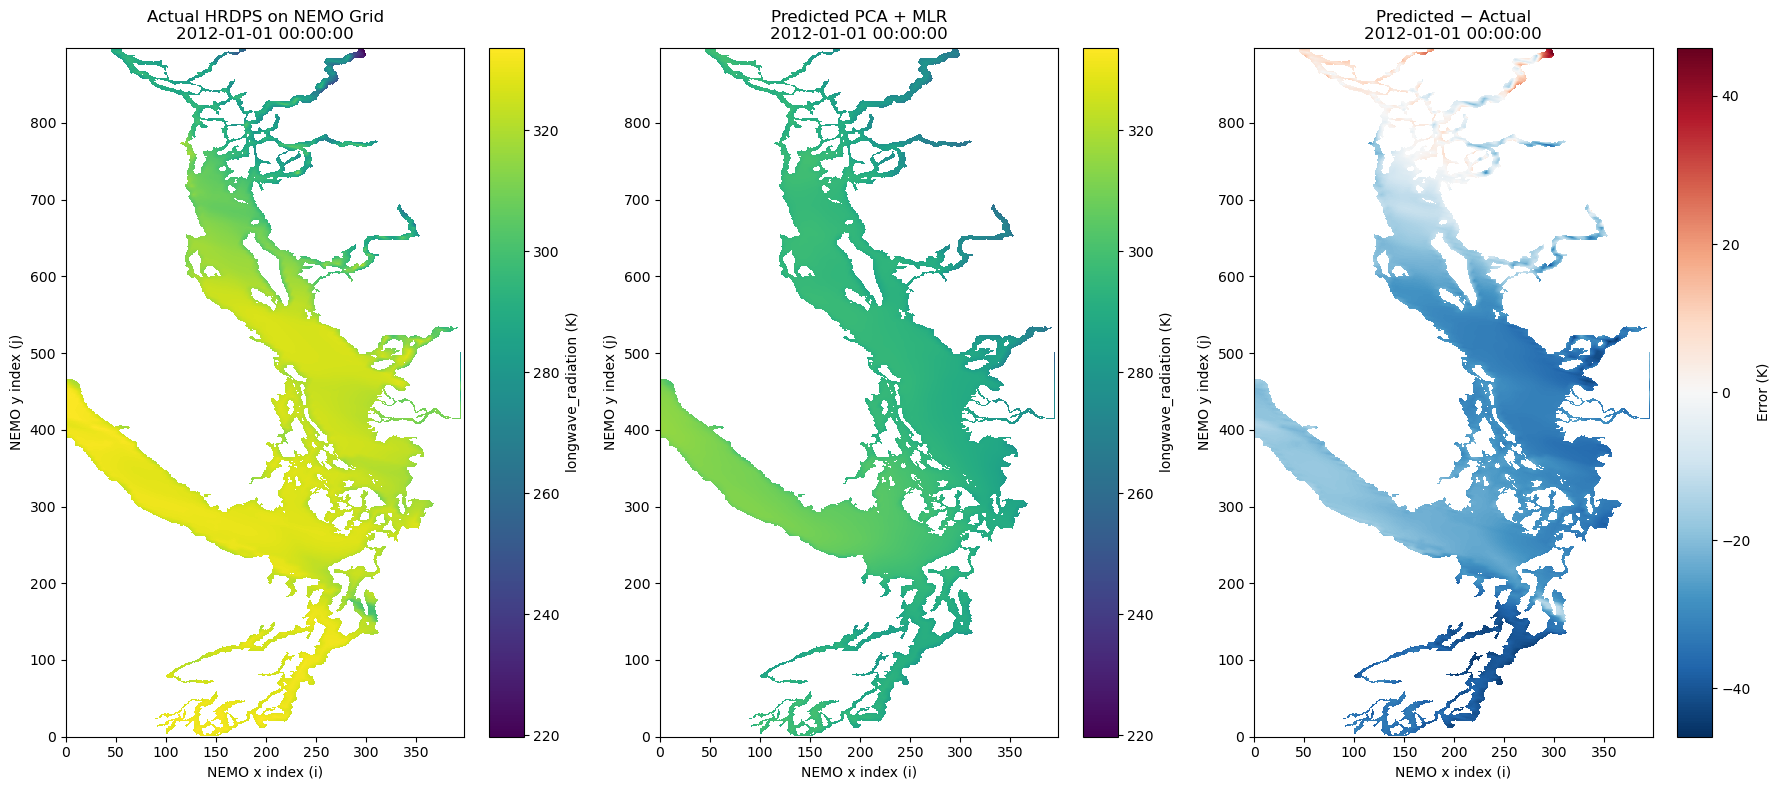

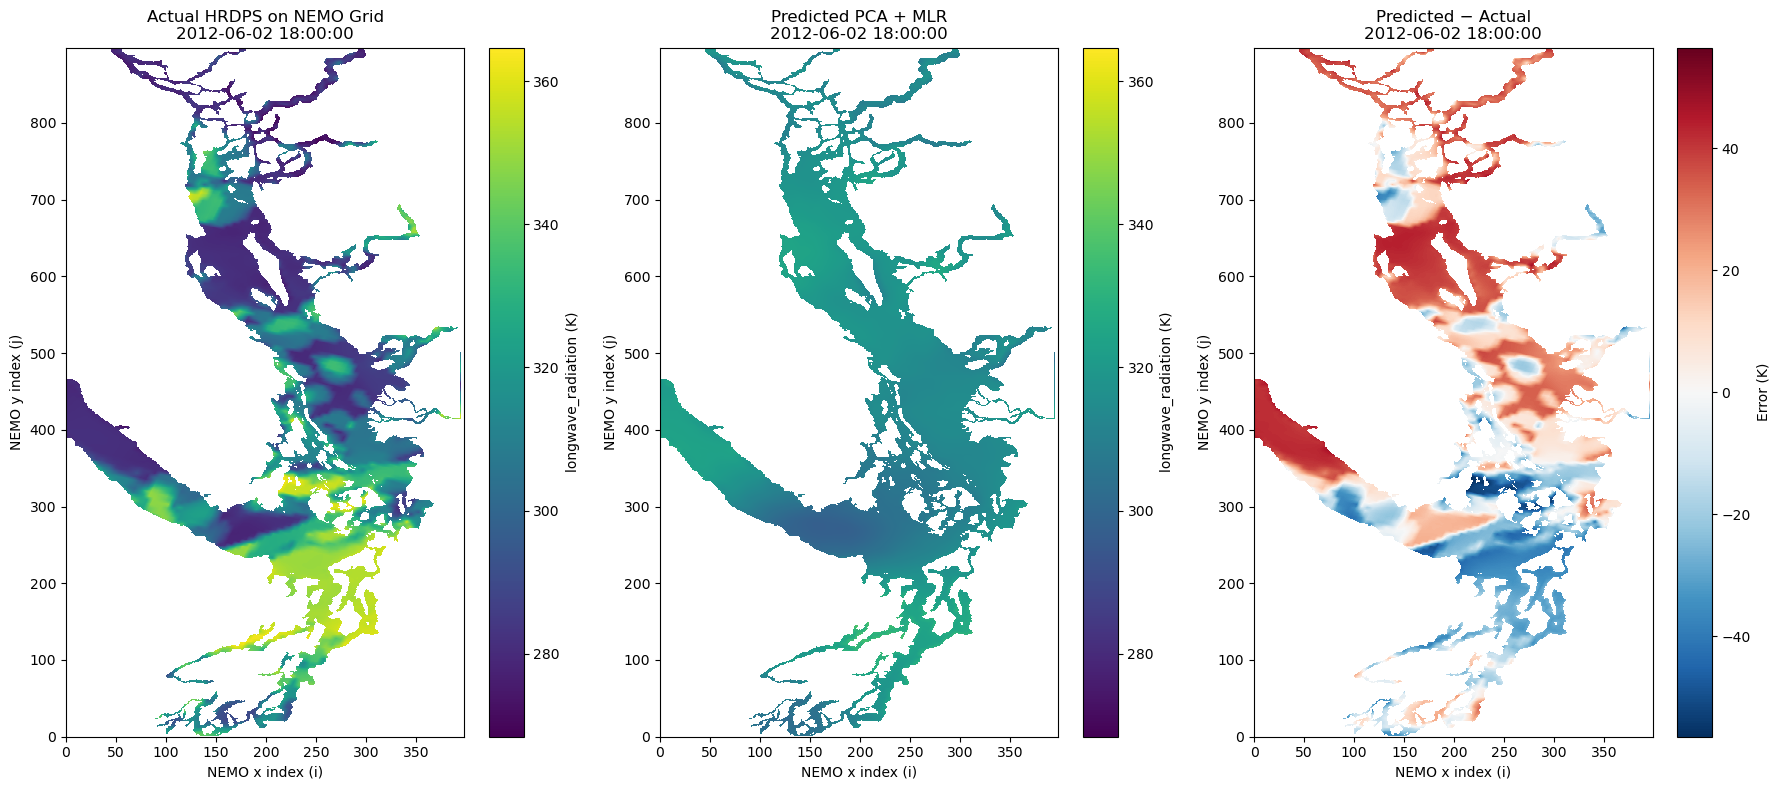

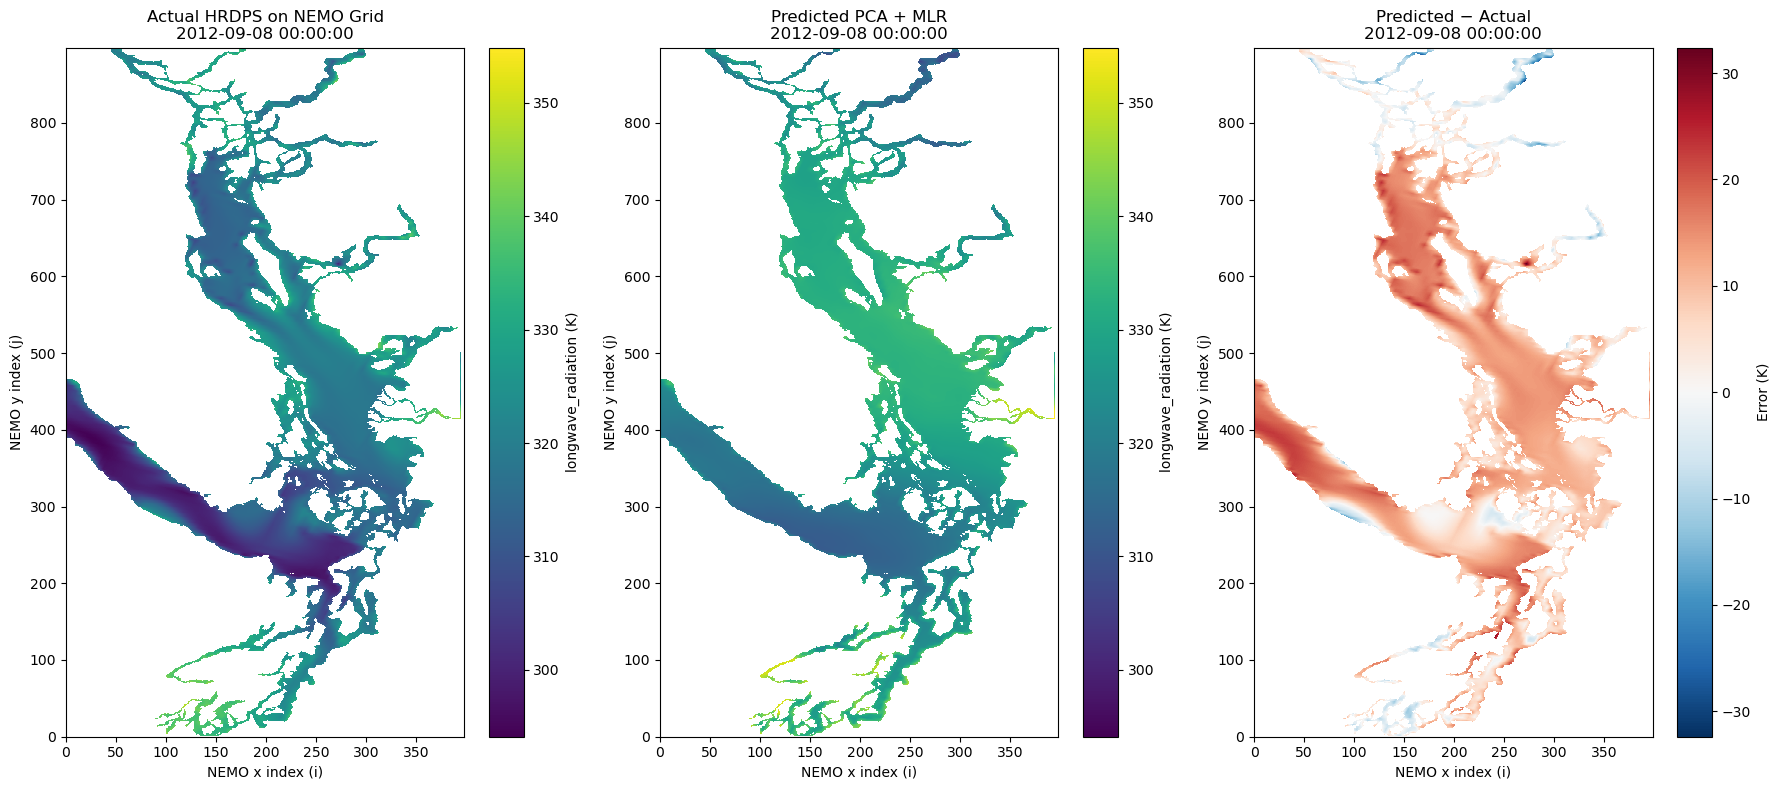

In [46]:
test_times = ds_hrdps_test["time_counter"].values

plot_actual_predicted_error(
    time_index=0,
    X_actual=X_hrdps_test,
    X_predicted=X_hrdps_test_pred_lr,
    times=test_times
)

plot_actual_predicted_error(
    time_index=1222,
    X_actual=X_hrdps_test,
    X_predicted=X_hrdps_test_pred_lr,
    times=test_times
)

plot_actual_predicted_error(
    time_index=2000,
    X_actual=X_hrdps_test,
    X_predicted=X_hrdps_test_pred_lr,
    times=test_times
)

In [47]:
def make_spatial_mean_timeseries(actual_matrix,predicted_matrix,times):
    actual_mean = np.mean(actual_matrix,axis=1)
    predicted_mean = np.mean(predicted_matrix,axis=1)
    timeseries = pd.DataFrame({"actual": actual_mean,"predicted": predicted_mean},index=pd.to_datetime(times))
    timeseries.index.name = "Date"
    return timeseries

In [48]:
val_times = ds_hrdps_val["time_counter"].values
test_times = ds_hrdps_test["time_counter"].values

longwave_radiation_timeseries_2008 = make_spatial_mean_timeseries(
    actual_matrix=X_hrdps_val,
    predicted_matrix=X_hrdps_val_pred_lr,
    times=val_times
)

longwave_radiation_timeseries_2012 = make_spatial_mean_timeseries(
    actual_matrix=X_hrdps_test,
    predicted_matrix=X_hrdps_test_pred_lr,
    times=test_times
)

print(longwave_radiation_timeseries_2008.head())
print()
print(longwave_radiation_timeseries_2012.head())

                         actual   predicted
Date                                       
2008-01-01 00:00:00  266.228241  267.717712
2008-01-01 03:00:00  285.618164  280.427582
2008-01-01 06:00:00  321.078766  289.740417
2008-01-01 09:00:00  321.762726  294.449554
2008-01-01 12:00:00  321.904236  313.235260

                         actual   predicted
Date                                       
2012-01-01 00:00:00  319.076324  294.924591
2012-01-01 03:00:00  323.271393  304.388245
2012-01-01 06:00:00  327.496643  307.067657
2012-01-01 09:00:00  331.461151  297.525177
2012-01-01 12:00:00  327.025848  306.688416


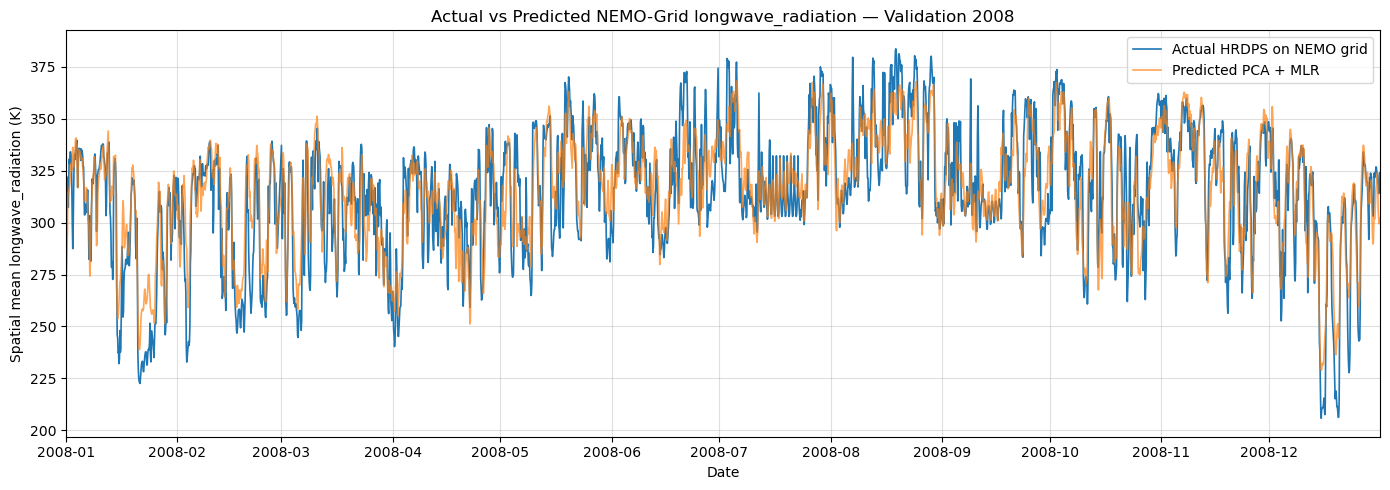

In [49]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(longwave_radiation_timeseries_2008.index,longwave_radiation_timeseries_2008["actual"],label="Actual HRDPS on NEMO grid",linewidth=1.2)
ax.plot(longwave_radiation_timeseries_2008.index,longwave_radiation_timeseries_2008["predicted"],label="Predicted PCA + MLR",linewidth=1.2,alpha=0.7)
ax.set_xlim(pd.Timestamp("2008-01-01"),pd.Timestamp("2008-12-31 23:59:59"))
ax.set_xlabel("Date")
ax.set_ylabel("Spatial mean longwave_radiation (K)")
ax.set_title("Actual vs Predicted NEMO-Grid longwave_radiation — Validation 2008")
ax.legend()
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

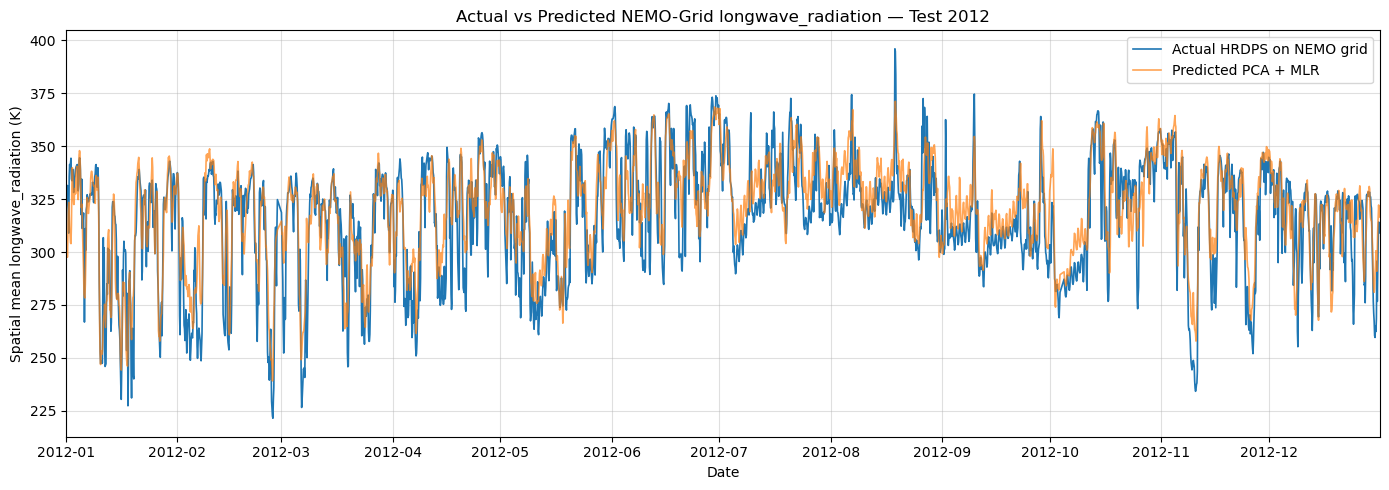

In [50]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(longwave_radiation_timeseries_2012.index,longwave_radiation_timeseries_2012["actual"],label="Actual HRDPS on NEMO grid",linewidth=1.2)
ax.plot(longwave_radiation_timeseries_2012.index,longwave_radiation_timeseries_2012["predicted"],label="Predicted PCA + MLR",linewidth=1.2,alpha=0.7)
ax.set_xlim(pd.Timestamp("2012-01-01"),pd.Timestamp("2012-12-31 23:59:59"))
ax.set_xlabel("Date")
ax.set_ylabel("Spatial mean longwave_radiation (K)")
ax.set_title("Actual vs Predicted NEMO-Grid longwave_radiation — Test 2012")
ax.legend()
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

In [51]:
stations = {"Sand Heads": {"j": 426,"i": 293},
    "Halibut Bank": {"j": 503,"i": 261},
    "Sentry Shoal": {"j": 707,"i": 145}}

In [52]:
def find_station_column(station_j, station_i):
    matches = np.where((valid_nemo_j == station_j)& (valid_nemo_i == station_i))[0]
    return int(matches[0])

for station_name, station_info in stations.items():
    column = find_station_column(station_info["j"],station_info["i"])
    stations[station_name]["column"] = column
    print(station_name,"j =", station_info["j"],"i =", station_info["i"],"matrix column =", column)

Sand Heads j = 426 i = 293 matrix column = 44165
Halibut Bank j = 503 i = 261 matrix column = 53329
Sentry Shoal j = 707 i = 145 matrix column = 71870


In [54]:
test_times = pd.to_datetime(ds_hrdps_test["time_counter"].values)
station_timeseries = {}
station_rmse = {}
station_normalized_rmse = {}

for station_name, station_info in stations.items():
    column = station_info["column"]

    actual = X_hrdps_test[:, column]
    predicted = X_hrdps_test_pred_lr[:, column]

    station_df = pd.DataFrame({"actual": actual,"predicted": predicted},index=test_times)
    station_df.index.name = "Date"
    rmse = np.sqrt(mean_squared_error(station_df["actual"],station_df["predicted"]))
    actual_std = np.std(station_df["actual"],ddof=0)
    normalized_rmse = rmse / actual_std
    station_timeseries[station_name] = station_df
    station_rmse[station_name] = rmse
    station_normalized_rmse[station_name] = normalized_rmse
    print(f"{station_name} RMSE: {rmse:.4f} ")
    print(f"{station_name} Normalized RMSE: {normalized_rmse:.4f} ({normalized_rmse * 100:.2f}%)")

Sand Heads RMSE: 21.2657 
Sand Heads Normalized RMSE: 0.6613 (66.13%)
Halibut Bank RMSE: 21.0009 
Halibut Bank Normalized RMSE: 0.6523 (65.23%)
Sentry Shoal RMSE: 21.4171 
Sentry Shoal Normalized RMSE: 0.6490 (64.90%)


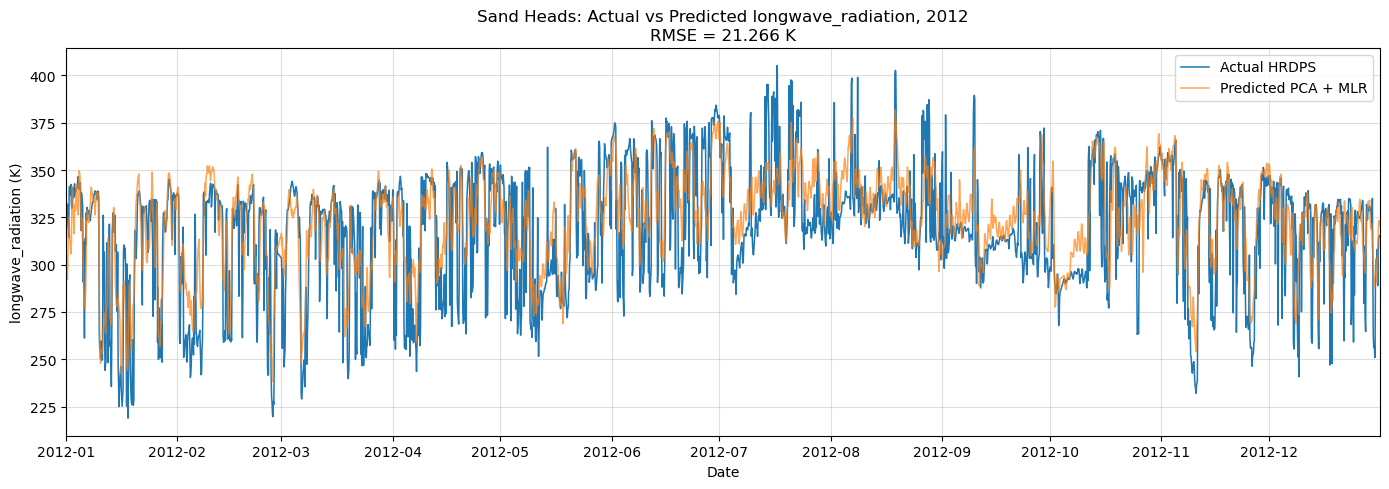

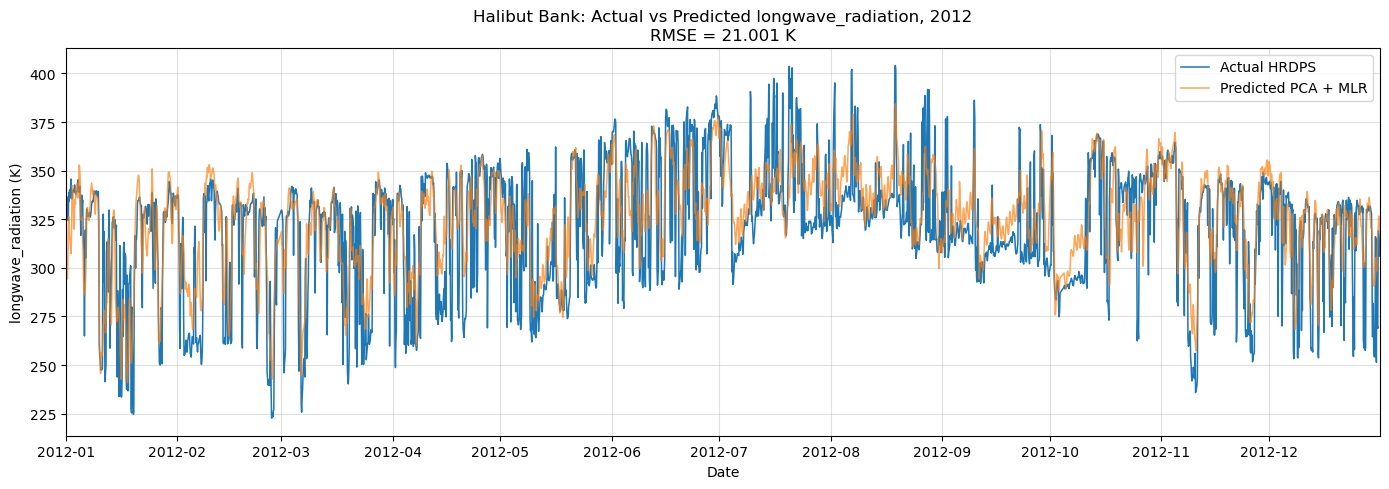

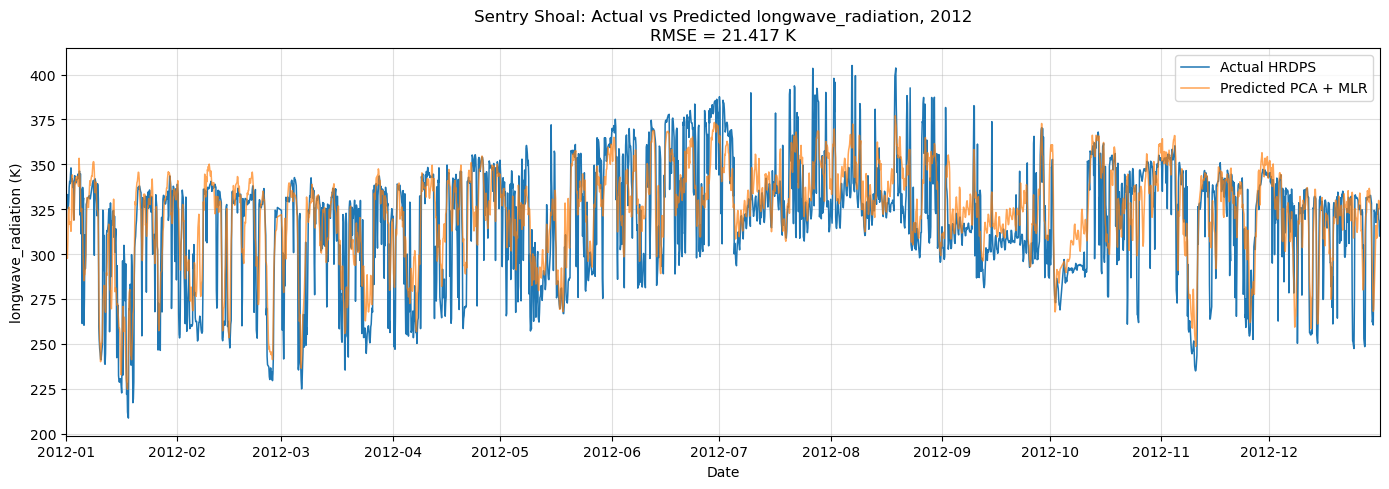

In [55]:
for station_name, station_df in station_timeseries.items():
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(station_df.index,station_df["actual"],label="Actual HRDPS",linewidth=1.1)
    ax.plot(station_df.index,station_df["predicted"],label="Predicted PCA + MLR",linewidth=1.1,alpha=0.7)
    ax.set_xlim(pd.Timestamp("2012-01-01"),pd.Timestamp("2012-12-31 23:59:59"))
    ax.set_xlabel("Date")
    ax.set_ylabel("longwave_radiation (K)")
    ax.set_title(f"{station_name}: Actual vs Predicted longwave_radiation, 2012\n"f"RMSE = {station_rmse[station_name]:.3f} K")
    ax.legend()
    ax.grid(True, alpha=0.4)
    plt.tight_layout()
    plt.show()

In [56]:
station_rmse_table = pd.DataFrame({"Station": list(station_rmse.keys()),"RMSE_K": list(station_rmse.values()),"Normalized_RMSE": list(station_normalized_rmse.values())})
station_rmse_table["Normalized_RMSE_Percent"] = station_rmse_table["Normalized_RMSE"] * 100
average_station_rmse = station_rmse_table["RMSE_K"].mean()
average_station_normalized_rmse = station_rmse_table["Normalized_RMSE"].mean()
print(station_rmse_table.to_string(index=False))
print(f"\nAverage RMSE across the three stations: {average_station_rmse:.4f}")
print(f"Average normalized RMSE across the three stations: {average_station_normalized_rmse:.4f} ({average_station_normalized_rmse * 100:.2f}%)")

     Station    RMSE_K  Normalized_RMSE  Normalized_RMSE_Percent
  Sand Heads 21.265704         0.661286                66.128600
Halibut Bank 21.000903         0.652257                65.225735
Sentry Shoal 21.417129         0.649030                64.902987

Average RMSE across the three stations: 21.2279
Average normalized RMSE across the three stations: 0.6542 (65.42%)


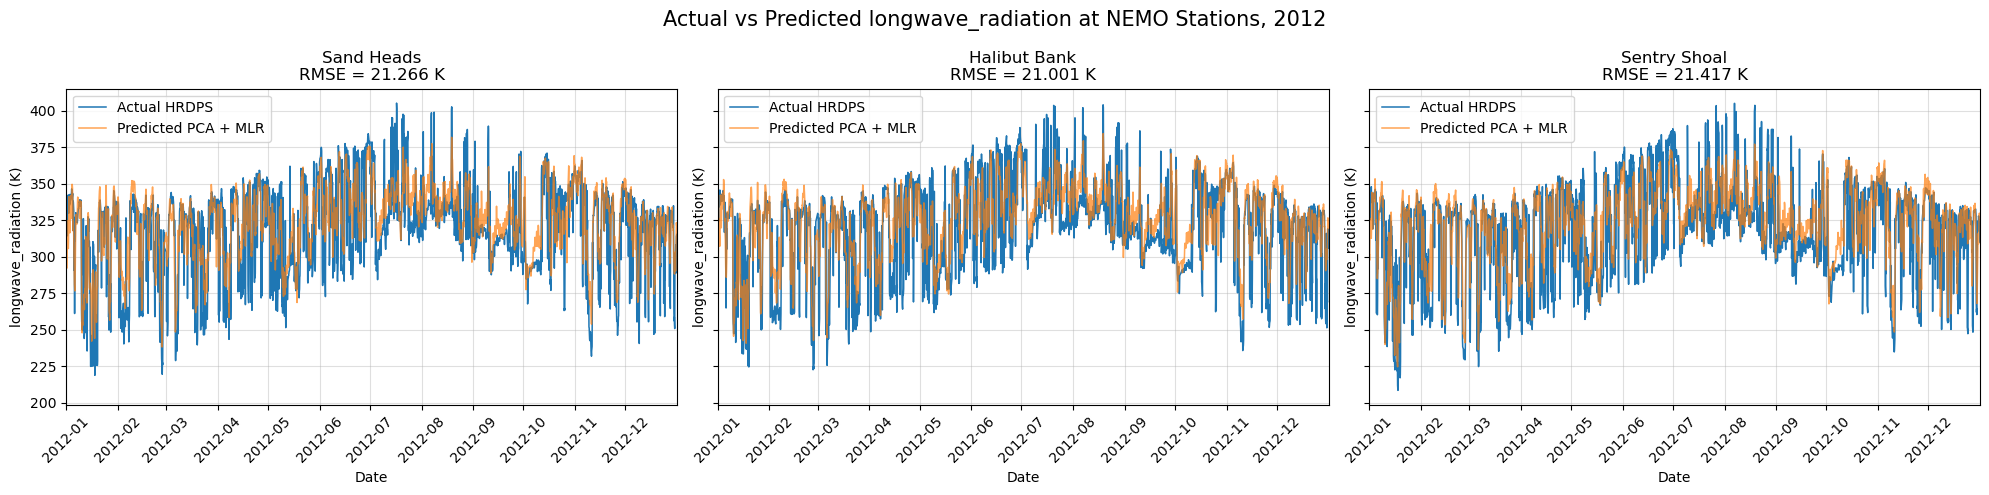

In [57]:
fig, axes = plt.subplots(1,3,figsize=(20, 5),sharey=True)
for ax, (station_name, station_df) in zip(axes,station_timeseries.items()):
    ax.plot(station_df.index,station_df["actual"],label="Actual HRDPS",linewidth=1.1)
    ax.plot(station_df.index,station_df["predicted"],label="Predicted PCA + MLR",linewidth=1.1,alpha=0.7)
    ax.set_xlim(pd.Timestamp("2012-01-01"),pd.Timestamp("2012-12-31 23:59:59"))
    ax.set_xlabel("Date")
    ax.set_ylabel("longwave_radiation (K)")
    ax.set_title(f"{station_name}\n"f"RMSE = {station_rmse[station_name]:.3f} K")
    ax.legend()
    ax.grid(True, alpha=0.4)
    ax.tick_params(axis="x",rotation=45)

fig.suptitle(
    "Actual vs Predicted longwave_radiation at NEMO Stations, 2012",
    fontsize=15
)

plt.tight_layout()
plt.show()

In [58]:
hrdps_train_residuals = (hrdps_train_scores - hrdps_train_scores_pred_lr).astype(np.float32)
hrdps_val_residuals = (hrdps_val_scores - hrdps_val_scores_pred_lr).astype(np.float32)
hrdps_test_residuals = (hrdps_test_scores - hrdps_test_scores_pred_lr).astype(np.float32)
print("Training residual shape:", hrdps_train_residuals.shape)
print("Validation residual shape:", hrdps_val_residuals.shape)
print("Test residual shape:", hrdps_test_residuals.shape)
print("Mean training residual:", np.mean(hrdps_train_residuals))
print("Mean validation residual:", np.mean(hrdps_val_residuals))
print("Mean test residual:", np.mean(hrdps_test_residuals))
assert hrdps_train_residuals.shape == hrdps_train_scores.shape
assert hrdps_val_residuals.shape == hrdps_val_scores.shape
assert hrdps_test_residuals.shape == hrdps_test_scores.shape

Training residual shape: (8760, 59)
Validation residual shape: (2920, 59)
Test residual shape: (2912, 59)
Mean training residual: 2.6535956e-05
Mean validation residual: -7.1395264
Mean test residual: -13.360478


In [59]:
train_target_pc_std = np.std(hrdps_train_scores, axis=0)

train_residual_pc_std = np.std(hrdps_train_residuals, axis=0)

residual_fraction = np.divide(train_residual_pc_std, train_target_pc_std, out=np.full_like(train_residual_pc_std, np.nan), where=train_target_pc_std != 0)

residual_diagnostics = pd.DataFrame({"PC": np.arange(1, n_hrdps_pcs + 1), "Target_PC_Std": train_target_pc_std, "LR_Residual_Std": train_residual_pc_std, "Residual_to_Target_Std_Ratio": residual_fraction})

print(residual_diagnostics.head(10).to_string(index=False))

print("\nMean residual-to-target standard deviation ratio:", np.nanmean(residual_fraction))

 PC  Target_PC_Std  LR_Residual_Std  Residual_to_Target_Std_Ratio
  1    8534.956055      4421.340820                      0.518027
  2    2581.456055      2126.989502                      0.823950
  3    1534.216431      1445.428467                      0.942128
  4    1422.434692      1172.763672                      0.824476
  5    1134.561768      1058.688721                      0.933126
  6    1027.111694       966.428406                      0.940919
  7     872.911743       778.778992                      0.892162
  8     797.607422       763.600952                      0.957364
  9     716.267273       683.088135                      0.953678
 10     646.654175       623.738770                      0.964563

Mean residual-to-target standard deviation ratio: 0.96398973


In [60]:
residual_input_scaler = StandardScaler()

X_train_residual_nn = residual_input_scaler.fit_transform(X_train_pc_final).astype(np.float32)

X_val_residual_nn = residual_input_scaler.transform(X_val_pc_final).astype(np.float32)

X_test_residual_nn = residual_input_scaler.transform(X_test_pc_final).astype(np.float32)

Y_train_residual_nn = hrdps_train_residuals.astype(np.float32)

Y_val_residual_nn = hrdps_val_residuals.astype(np.float32)

Y_test_residual_nn = hrdps_test_residuals.astype(np.float32)

print("Residual FCNN training inputs:", X_train_residual_nn.shape)

print("Residual FCNN validation inputs:", X_val_residual_nn.shape)

print("Residual FCNN test inputs:", X_test_residual_nn.shape)

print("Residual FCNN training targets:", Y_train_residual_nn.shape)

print("Residual FCNN validation targets:", Y_val_residual_nn.shape)

print("Residual FCNN test targets:", Y_test_residual_nn.shape)

print("Training input mean:", np.mean(X_train_residual_nn))

print("Training input standard deviation:", np.std(X_train_residual_nn))

Residual FCNN training inputs: (8760, 73)
Residual FCNN validation inputs: (2920, 73)
Residual FCNN test inputs: (2912, 73)
Residual FCNN training targets: (8760, 59)
Residual FCNN validation targets: (2920, 59)
Residual FCNN test targets: (2912, 59)
Training input mean: -5.36878e-11
Training input standard deviation: 1.0


In [63]:
def build_residual_pc_fcnn(n_input_pcs, n_output_pcs):
    n_input_pcs = int(n_input_pcs)
    n_output_pcs = int(n_output_pcs)
    regularizer = tf.keras.regularizers.l2(1e-5)

    inputs = tf.keras.Input(shape=(n_input_pcs,), name="canrcm_longwave_pc_input")

    x = tf.keras.layers.Dense(64, activation="relu", kernel_initializer="he_normal", kernel_regularizer=regularizer, name="dense_1")(inputs)

    x = tf.keras.layers.Dense(64, activation="relu", kernel_initializer="he_normal", kernel_regularizer=regularizer, name="dense_2")(x)

    x = tf.keras.layers.Dense(32, activation="relu", kernel_initializer="he_normal", kernel_regularizer=regularizer, name="dense_3")(x)

    outputs = tf.keras.layers.Dense(n_output_pcs, activation="linear", kernel_initializer="zeros", bias_initializer="zeros", name="predicted_hrdps_pc_residuals")(x)

    model = tf.keras.Model(inputs=inputs, outputs=outputs, name="longwave_residual_pc_fcnn")

    return model

In [64]:
seed = 42

tf.keras.backend.clear_session()

np.random.seed(seed)

tf.keras.utils.set_random_seed(seed)

n_residual_input_pcs = int(X_train_residual_nn.shape[1])

n_residual_output_pcs = int(hrdps_train_residuals.shape[1])

print("Input PCs:", n_residual_input_pcs, type(n_residual_input_pcs))

print("Output residual PCs:", n_residual_output_pcs, type(n_residual_output_pcs))

print("n_hrdps_pcs:", n_hrdps_pcs, type(n_hrdps_pcs))

residual_pc_fcnn = build_residual_pc_fcnn(
    n_input_pcs=n_residual_input_pcs,
    n_output_pcs=n_residual_output_pcs
)

residual_optimizer = tf.keras.optimizers.Adam(
    learning_rate=1e-3,
    clipnorm=1.0
)

residual_pc_fcnn.compile(
    optimizer=residual_optimizer,
    loss="mse",
    metrics=[
        tf.keras.metrics.MeanAbsoluteError(
            name="mae"
        )
    ]
)

residual_pc_fcnn.summary()

Input PCs: 73 <class 'int'>
Output residual PCs: 59 <class 'int'>
n_hrdps_pcs: 59 <class 'numpy.int64'>


Model: "longwave_residual_pc_fcnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ canrcm_longwave_pc_input        │ (None, 73)             │             0 │
│ (InputLayer)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predicted_hrdps_pc_residuals    │ (None, 59)             │         1,947 │
│ (Dense)                         │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,923 (50.48 KB)

 Trainable params: 12,923 (50.48 KB)

 Non-trainable params: 0 (0.00 B)

In [65]:
residual_output_dir = "/ocean/dtaneja/MOAD/analysis-dishika/notebooks/Neural_Networks/longwave_residual_fcnn"

os.makedirs(residual_output_dir, exist_ok=True)

residual_checkpoint_path = os.path.join(residual_output_dir, "best_longwave_residual_pc_fcnn.keras")

print("Residual FCNN checkpoint:", residual_checkpoint_path)

residual_callbacks = [
    tf.keras.callbacks.ModelCheckpoint(residual_checkpoint_path, monitor="val_loss", mode="min", save_best_only=True, verbose=1),
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", mode="min", patience=15, min_delta=1e-4, restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", mode="min", factor=0.5, patience=5, min_lr=1e-6, verbose=1)
]

Residual FCNN checkpoint: /ocean/dtaneja/MOAD/analysis-dishika/notebooks/Neural_Networks/longwave_residual_fcnn/best_longwave_residual_pc_fcnn.keras


In [66]:
residual_history = residual_pc_fcnn.fit(X_train_residual_nn, Y_train_residual_nn, validation_data=(X_val_residual_nn, Y_val_residual_nn), epochs=300, batch_size=64, shuffle=True, callbacks=residual_callbacks, verbose=2)

Epoch 1/300

Epoch 1: val_loss improved from None to 648753.68750, saving model to /ocean/dtaneja/MOAD/analysis-dishika/notebooks/Neural_Networks/longwave_residual_fcnn/best_longwave_residual_pc_fcnn.keras

Epoch 1: finished saving model to /ocean/dtaneja/MOAD/analysis-dishika/notebooks/Neural_Networks/longwave_residual_fcnn/best_longwave_residual_pc_fcnn.keras
137/137 - 5s - 40ms/step - loss: 606066.6250 - mae: 332.4506 - val_loss: 648753.6875 - val_mae: 352.6316 - learning_rate: 0.0010
Epoch 2/300

Epoch 2: val_loss improved from 648753.68750 to 648747.25000, saving model to /ocean/dtaneja/MOAD/analysis-dishika/notebooks/Neural_Networks/longwave_residual_fcnn/best_longwave_residual_pc_fcnn.keras

Epoch 2: finished saving model to /ocean/dtaneja/MOAD/analysis-dishika/notebooks/Neural_Networks/longwave_residual_fcnn/best_longwave_residual_pc_fcnn.keras
137/137 - 0s - 3ms/step - loss: 606060.0625 - mae: 332.4489 - val_loss: 648747.2500 - val_mae: 352.6302 - learning_rate: 0.0010
Epoch 3

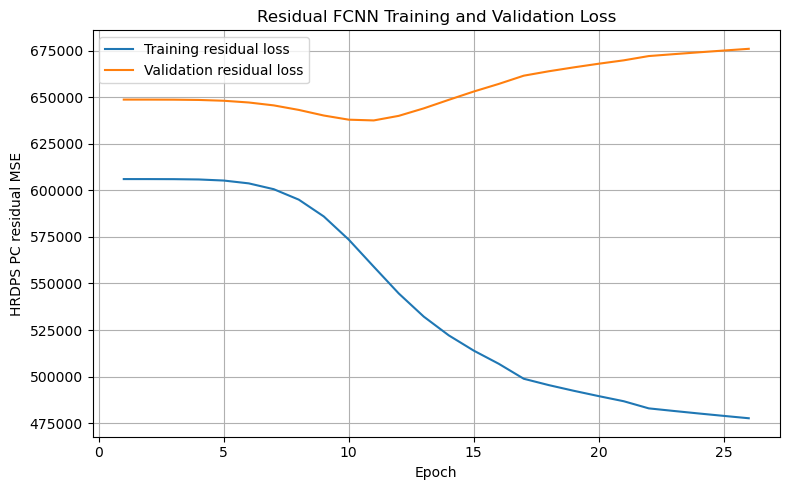

In [67]:
residual_epochs = range(1, len(residual_history.history["loss"]) + 1)

plt.figure(figsize=(8, 5))

plt.plot(residual_epochs, residual_history.history["loss"], label="Training residual loss")

plt.plot(residual_epochs, residual_history.history["val_loss"], label="Validation residual loss")

plt.xlabel("Epoch")

plt.ylabel("HRDPS PC residual MSE")

plt.title("Residual FCNN Training and Validation Loss")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()

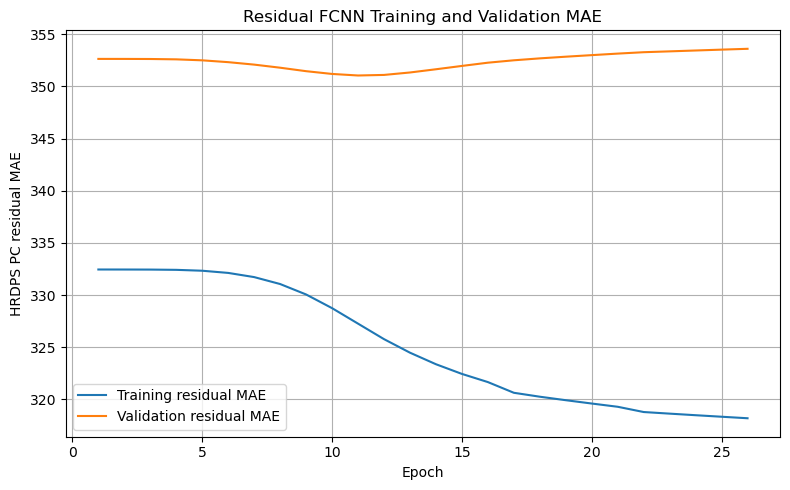

In [68]:
plt.figure(figsize=(8, 5))

plt.plot(residual_epochs, residual_history.history["mae"], label="Training residual MAE")

plt.plot(residual_epochs, residual_history.history["val_mae"], label="Validation residual MAE")

plt.xlabel("Epoch")

plt.ylabel("HRDPS PC residual MAE")

plt.title("Residual FCNN Training and Validation MAE")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()

In [69]:
best_residual_pc_fcnn = tf.keras.models.load_model(residual_checkpoint_path)

best_residual_pc_fcnn.summary()

Model: "longwave_residual_pc_fcnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ canrcm_longwave_pc_input        │ (None, 73)             │             0 │
│ (InputLayer)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predicted_hrdps_pc_residuals    │ (None, 59)             │         1,947 │
│ (Dense)                         │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 38,771 (151.45 KB)

 Trainable params: 12,923 (50.48 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 25,848 (100.97 KB)

In [70]:
hrdps_train_residuals_pred = best_residual_pc_fcnn.predict(X_train_residual_nn, batch_size=256, verbose=1).astype(np.float32)

hrdps_val_residuals_pred = best_residual_pc_fcnn.predict(X_val_residual_nn, batch_size=256, verbose=1).astype(np.float32)

hrdps_test_residuals_pred = best_residual_pc_fcnn.predict(X_test_residual_nn, batch_size=256, verbose=1).astype(np.float32)

print("Predicted training residuals:", hrdps_train_residuals_pred.shape)

print("Predicted validation residuals:", hrdps_val_residuals_pred.shape)

print("Predicted test residuals:", hrdps_test_residuals_pred.shape)

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Predicted training residuals: (8760, 59)
Predicted validation residuals: (2920, 59)
Predicted test residuals: (2912, 59)


In [71]:
def calculate_residual_rmse(actual_residuals, predicted_residuals):
    return np.sqrt(mean_squared_error(actual_residuals.ravel(), predicted_residuals.ravel()))

train_residual_rmse_lr = calculate_residual_rmse(hrdps_train_residuals, np.zeros_like(hrdps_train_residuals))

train_residual_rmse_fcnn = calculate_residual_rmse(hrdps_train_residuals, hrdps_train_residuals_pred)

val_residual_rmse_lr = calculate_residual_rmse(hrdps_val_residuals, np.zeros_like(hrdps_val_residuals))

val_residual_rmse_fcnn = calculate_residual_rmse(hrdps_val_residuals, hrdps_val_residuals_pred)

test_residual_rmse_lr = calculate_residual_rmse(hrdps_test_residuals, np.zeros_like(hrdps_test_residuals))

test_residual_rmse_fcnn = calculate_residual_rmse(hrdps_test_residuals, hrdps_test_residuals_pred)

residual_rmse_comparison = pd.DataFrame([
    {"Split": "Training", "Zero_Correction_RMSE": train_residual_rmse_lr, "FCNN_Residual_RMSE": train_residual_rmse_fcnn},
    {"Split": "Validation", "Zero_Correction_RMSE": val_residual_rmse_lr, "FCNN_Residual_RMSE": val_residual_rmse_fcnn},
    {"Split": "Test", "Zero_Correction_RMSE": test_residual_rmse_lr, "FCNN_Residual_RMSE": test_residual_rmse_fcnn}
])

residual_rmse_comparison["Improvement_Percent"] = 100 * (residual_rmse_comparison["Zero_Correction_RMSE"] - residual_rmse_comparison["FCNN_Residual_RMSE"]) / residual_rmse_comparison["Zero_Correction_RMSE"]

residual_rmse_comparison



,Split,Zero_Correction_RMSE,FCNN_Residual_RMSE,Improvement_Percent
0,Training,778.502288,740.147325,4.926763
1,Validation,805.452590,798.475657,0.866213
2,Test,785.781657,784.893026,0.113089


In [72]:
hrdps_train_scores_pred_final = (hrdps_train_scores_pred_lr + hrdps_train_residuals_pred).astype(np.float32)

hrdps_val_scores_pred_final = (hrdps_val_scores_pred_lr + hrdps_val_residuals_pred).astype(np.float32)

hrdps_test_scores_pred_final = (hrdps_test_scores_pred_lr + hrdps_test_residuals_pred).astype(np.float32)

print("Final training PC predictions:", hrdps_train_scores_pred_final.shape)

print("Final validation PC predictions:", hrdps_val_scores_pred_final.shape)

print("Final test PC predictions:", hrdps_test_scores_pred_final.shape)

Final training PC predictions: (8760, 59)
Final validation PC predictions: (2920, 59)
Final test PC predictions: (2912, 59)


In [73]:
X_hrdps_train_pred_final = inverse_from_selected_hrdps_pcs(hrdps_train_scores_pred_final, pca_hrdps, n_hrdps_pcs)

X_hrdps_val_pred_final = inverse_from_selected_hrdps_pcs(hrdps_val_scores_pred_final, pca_hrdps, n_hrdps_pcs)

X_hrdps_test_pred_final = inverse_from_selected_hrdps_pcs(hrdps_test_scores_pred_final, pca_hrdps, n_hrdps_pcs)

print("Actual training matrix:", X_hrdps_train.shape)

print("Final predicted training matrix:", X_hrdps_train_pred_final.shape)

print("Actual validation matrix:", X_hrdps_val.shape)

print("Final predicted validation matrix:", X_hrdps_val_pred_final.shape)

print("Actual test matrix:", X_hrdps_test.shape)

print("Final predicted test matrix:", X_hrdps_test_pred_final.shape)

Actual training matrix: (8760, 81383)
Final predicted training matrix: (8760, 81383)
Actual validation matrix: (2920, 81383)
Final predicted validation matrix: (2920, 81383)
Actual test matrix: (2912, 81383)
Final predicted test matrix: (2912, 81383)


In [74]:
val_metrics_final = calculate_metrics(X_hrdps_val, X_hrdps_val_pred_final, "Validation PCA + LR + Residual FCNN")

test_metrics_final = calculate_metrics(X_hrdps_test, X_hrdps_test_pred_final, "Test PCA + LR + Residual FCNN")


Validation PCA + LR + Residual FCNN
RMSE: 22.09383702024942
MAE:  17.149072647094727
Bias: 0.892664
R²:   0.6126655340194702
Actual standard deviation: 35.713814
Normalized RMSE: 0.6186356112868229
Normalized RMSE (%): 61.863561128682285

Test PCA + LR + Residual FCNN
RMSE: 21.812330010306457
MAE:  16.758176803588867
Bias: 3.7068927
R²:   0.5434741973876953
Actual standard deviation: 32.47443
Normalized RMSE: 0.6716770688117418
Normalized RMSE (%): 67.16770688117418


In [75]:
model_comparison = pd.DataFrame([
    {"Model": "PCA + LR", "Split": "Validation", **val_metrics_lr},
    {"Model": "PCA + LR + Residual FCNN", "Split": "Validation", **val_metrics_final},
    {"Model": "PCA + LR", "Split": "Test", **test_metrics_lr},
    {"Model": "PCA + LR + Residual FCNN", "Split": "Test", **test_metrics_final}
])

model_comparison

,Model,Split,RMSE,MAE,Bias,R2,Normalized_RMSE,Normalized_RMSE_percent
0,PCA + LR,Validation,22.276611,17.480091,1.032925,0.606228,0.623753,62.375336
1,PCA + LR + Residual FCNN,Validation,22.093837,17.149073,0.892664,0.612666,0.618636,61.863561
2,PCA + LR,Test,21.835467,16.945402,3.833726,0.542503,0.672390,67.238952
3,PCA + LR + Residual FCNN,Test,21.812330,16.758177,3.706893,0.543474,0.671677,67.167707


In [76]:
validation_rmse_improvement_percent = 100 * (val_metrics_lr["RMSE"] - val_metrics_final["RMSE"]) / val_metrics_lr["RMSE"]

test_rmse_improvement_percent = 100 * (test_metrics_lr["RMSE"] - test_metrics_final["RMSE"]) / test_metrics_lr["RMSE"]

validation_r2_change = val_metrics_final["R2"] - val_metrics_lr["R2"]

test_r2_change = test_metrics_final["R2"] - test_metrics_lr["R2"]

print("Validation RMSE improvement (%):", validation_rmse_improvement_percent)

print("Validation R² change:", validation_r2_change)

print("Test RMSE improvement (%):", test_rmse_improvement_percent)

print("Test R² change:", test_r2_change)

if val_metrics_final["RMSE"] < val_metrics_lr["RMSE"]:
    print("\nThe residual FCNN improves validation RMSE over PCA + LR.")
else:
    print("\nThe residual FCNN does not improve validation RMSE over PCA + LR.")

Validation RMSE improvement (%): 0.8204756363693133
Validation R² change: 0.006437361240386963
Test RMSE improvement (%): 0.10595834290393905
Test R² change: 0.0009709596633911133

The residual FCNN improves validation RMSE over PCA + LR.


In [77]:
val_pc_r2_lr = r2_score(hrdps_val_scores, hrdps_val_scores_pred_lr, multioutput="variance_weighted")

val_pc_r2_final = r2_score(hrdps_val_scores, hrdps_val_scores_pred_final, multioutput="variance_weighted")

test_pc_r2_lr = r2_score(hrdps_test_scores, hrdps_test_scores_pred_lr, multioutput="variance_weighted")

test_pc_r2_final = r2_score(hrdps_test_scores, hrdps_test_scores_pred_final, multioutput="variance_weighted")

val_pc_rmse_lr = np.sqrt(mean_squared_error(hrdps_val_scores.ravel(), hrdps_val_scores_pred_lr.ravel()))

val_pc_rmse_final = np.sqrt(mean_squared_error(hrdps_val_scores.ravel(), hrdps_val_scores_pred_final.ravel()))

test_pc_rmse_lr = np.sqrt(mean_squared_error(hrdps_test_scores.ravel(), hrdps_test_scores_pred_lr.ravel()))

test_pc_rmse_final = np.sqrt(mean_squared_error(hrdps_test_scores.ravel(), hrdps_test_scores_pred_final.ravel()))

pc_space_comparison = pd.DataFrame([
    {"Model": "PCA + LR", "Split": "Validation", "PC_RMSE": val_pc_rmse_lr, "PC_R2": val_pc_r2_lr},
    {"Model": "PCA + LR + Residual FCNN", "Split": "Validation", "PC_RMSE": val_pc_rmse_final, "PC_R2": val_pc_r2_final},
    {"Model": "PCA + LR", "Split": "Test", "PC_RMSE": test_pc_rmse_lr, "PC_R2": test_pc_r2_lr},
    {"Model": "PCA + LR + Residual FCNN", "Split": "Test", "PC_RMSE": test_pc_rmse_final, "PC_R2": test_pc_r2_final}
])

pc_space_comparison

,Model,Split,PC_RMSE,PC_R2
0,PCA + LR,Validation,805.452590,0.618971
1,PCA + LR + Residual FCNN,Validation,798.475657,0.625544
2,PCA + LR,Test,785.781657,0.558300
3,PCA + LR + Residual FCNN,Test,784.893026,0.559299


In [78]:
X_hrdps_val_pca_only = inverse_from_selected_hrdps_pcs(hrdps_val_scores, pca_hrdps, n_hrdps_pcs)

X_hrdps_test_pca_only = inverse_from_selected_hrdps_pcs(hrdps_test_scores, pca_hrdps, n_hrdps_pcs)

val_metrics_pca_only = calculate_metrics(X_hrdps_val, X_hrdps_val_pca_only, "Validation 98% PCA reconstruction ceiling")

test_metrics_pca_only = calculate_metrics(X_hrdps_test, X_hrdps_test_pca_only, "Test 98% PCA reconstruction ceiling")


Validation 98% PCA reconstruction ceiling
RMSE: 5.091573238400111
MAE:  3.111537218093872
Bias: -6.929908e-05
R²:   0.9794293642044067
Actual standard deviation: 35.713814
Normalized RMSE: 0.14256593455733393
Normalized RMSE (%): 14.256593455733393

Test 98% PCA reconstruction ceiling
RMSE: 5.399640579977924
MAE:  3.264580488204956
Bias: -0.00018797182
R²:   0.9720234870910645
Actual standard deviation: 32.47443
Normalized RMSE: 0.16627360560209817
Normalized RMSE (%): 16.627360560209816


In [79]:
full_model_comparison = pd.DataFrame([
    {"Model": "98% PCA reconstruction ceiling", "Split": "Validation", **val_metrics_pca_only},
    {"Model": "PCA + LR", "Split": "Validation", **val_metrics_lr},
    {"Model": "PCA + LR + Residual FCNN", "Split": "Validation", **val_metrics_final},
    {"Model": "98% PCA reconstruction ceiling", "Split": "Test", **test_metrics_pca_only},
    {"Model": "PCA + LR", "Split": "Test", **test_metrics_lr},
    {"Model": "PCA + LR + Residual FCNN", "Split": "Test", **test_metrics_final}
])

full_model_comparison

,Model,Split,RMSE,MAE,Bias,R2,Normalized_RMSE,Normalized_RMSE_percent
0,98% PCA reconstruction ceiling,Validation,5.091573,3.111537,-0.000069,0.979429,0.142566,14.256593
1,PCA + LR,Validation,22.276611,17.480091,1.032925,0.606228,0.623753,62.375336
2,PCA + LR + Residual FCNN,Validation,22.093837,17.149073,0.892664,0.612666,0.618636,61.863561
3,98% PCA reconstruction ceiling,Test,5.399641,3.264580,-0.000188,0.972023,0.166274,16.627361
4,PCA + LR,Test,21.835467,16.945402,3.833726,0.542503,0.672390,67.238952
5,PCA + LR + Residual FCNN,Test,21.812330,16.758177,3.706893,0.543474,0.671677,67.167707


In [80]:
station_comparison_rows = []

for station_name, station_info in stations.items():
    column = station_info["column"]

    actual_station = X_hrdps_test[:, column]

    predicted_station_lr = X_hrdps_test_pred_lr[:, column]

    predicted_station_final = X_hrdps_test_pred_final[:, column]

    rmse_lr = np.sqrt(mean_squared_error(actual_station, predicted_station_lr))

    rmse_final = np.sqrt(mean_squared_error(actual_station, predicted_station_final))

    actual_station_std = np.std(actual_station, ddof=0)

    normalized_rmse_lr = rmse_lr / actual_station_std

    normalized_rmse_final = rmse_final / actual_station_std

    station_comparison_rows.append({
        "Station": station_name,
        "LR_RMSE": rmse_lr,
        "Residual_FCNN_RMSE": rmse_final,
        "RMSE_Improvement_Percent": 100 * (rmse_lr - rmse_final) / rmse_lr,
        "LR_Normalized_RMSE": normalized_rmse_lr,
        "Residual_FCNN_Normalized_RMSE": normalized_rmse_final
    })

station_model_comparison = pd.DataFrame(station_comparison_rows)

station_model_comparison

,Station,LR_RMSE,Residual_FCNN_RMSE,RMSE_Improvement_Percent,LR_Normalized_RMSE,Residual_FCNN_Normalized_RMSE
0,Sand Heads,21.265704,21.234394,0.147234,0.661286,0.660312
1,Halibut Bank,21.000903,21.004810,-0.018605,0.652257,0.652379
2,Sentry Shoal,21.417129,21.368904,0.225170,0.649030,0.647568


In [81]:
val_times = ds_hrdps_val["time_counter"].values

test_times = ds_hrdps_test["time_counter"].values

longwave_timeseries_val_lr = make_spatial_mean_timeseries(X_hrdps_val, X_hrdps_val_pred_lr, val_times)

longwave_timeseries_val_final = make_spatial_mean_timeseries(X_hrdps_val, X_hrdps_val_pred_final, val_times)

longwave_timeseries_test_lr = make_spatial_mean_timeseries(X_hrdps_test, X_hrdps_test_pred_lr, test_times)

longwave_timeseries_test_final = make_spatial_mean_timeseries(X_hrdps_test, X_hrdps_test_pred_final, test_times)

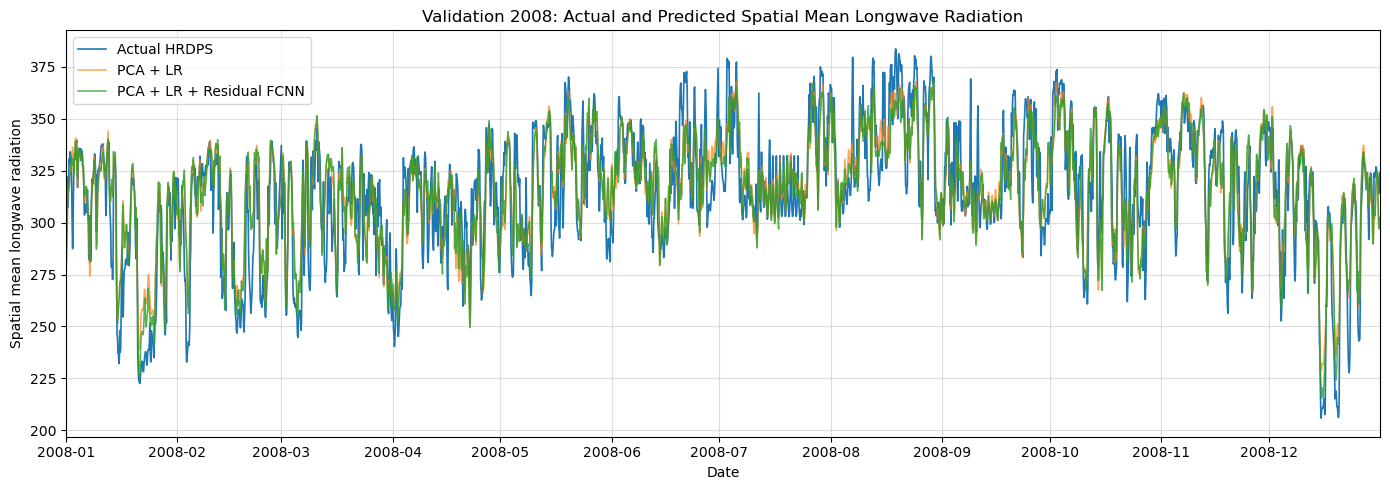

In [82]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(longwave_timeseries_val_lr.index, longwave_timeseries_val_lr["actual"], label="Actual HRDPS", linewidth=1.2)

ax.plot(longwave_timeseries_val_lr.index, longwave_timeseries_val_lr["predicted"], label="PCA + LR", linewidth=1.1, alpha=0.7)

ax.plot(longwave_timeseries_val_final.index, longwave_timeseries_val_final["predicted"], label="PCA + LR + Residual FCNN", linewidth=1.1, alpha=0.8)

ax.set_xlim(pd.Timestamp("2008-01-01"), pd.Timestamp("2008-12-31 23:59:59"))

ax.set_xlabel("Date")

ax.set_ylabel("Spatial mean longwave radiation")

ax.set_title("Validation 2008: Actual and Predicted Spatial Mean Longwave Radiation")

ax.legend()

ax.grid(True, alpha=0.4)

plt.tight_layout()

plt.show()

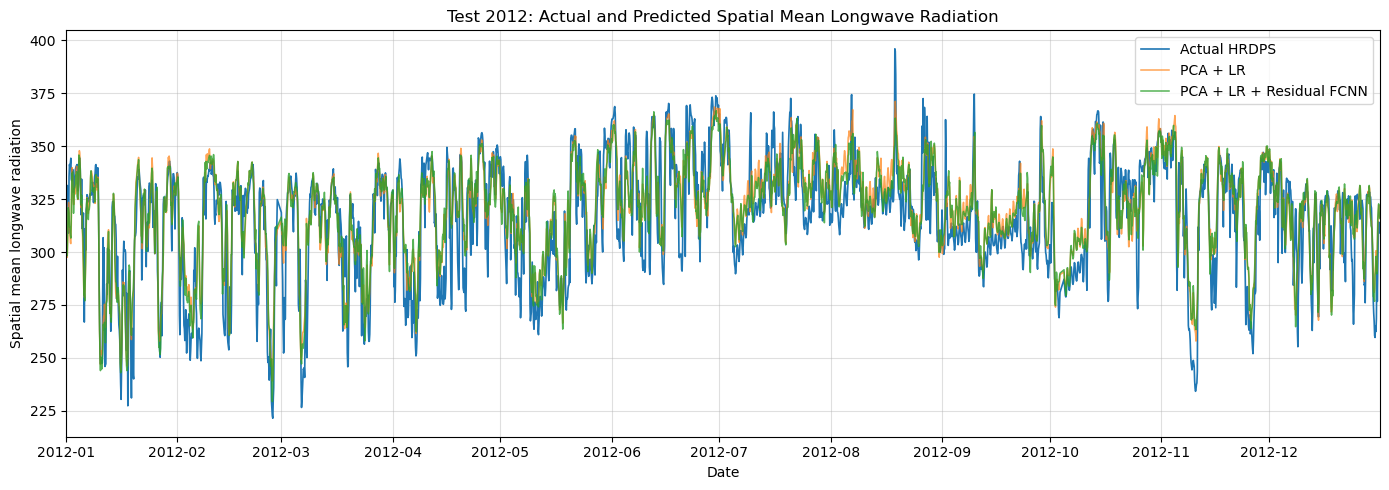

In [83]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(longwave_timeseries_test_lr.index, longwave_timeseries_test_lr["actual"], label="Actual HRDPS", linewidth=1.2)

ax.plot(longwave_timeseries_test_lr.index, longwave_timeseries_test_lr["predicted"], label="PCA + LR", linewidth=1.1, alpha=0.7)

ax.plot(longwave_timeseries_test_final.index, longwave_timeseries_test_final["predicted"], label="PCA + LR + Residual FCNN", linewidth=1.1, alpha=0.8)

ax.set_xlim(pd.Timestamp("2012-01-01"), pd.Timestamp("2012-12-31 23:59:59"))

ax.set_xlabel("Date")

ax.set_ylabel("Spatial mean longwave radiation")

ax.set_title("Test 2012: Actual and Predicted Spatial Mean Longwave Radiation")

ax.legend()

ax.grid(True, alpha=0.4)

plt.tight_layout()

plt.show()